## Stationarity test

Stationarity- It shows the mean value of the series that remains constant over the time period. If past effects accumulate and the values increase towards infinity then stationarity is not met.

In [1]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from dateutil.parser import parse

import seaborn as sns
import numpy as np
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

from matplotlib.gridspec import GridSpec
from matplotlib.dates import DateFormatter

We use Augmented Dickey-Fuller (ADF) test to check the stationarity of the Time Series
H0: None stationary (unit root)
H1: Time Series is Stationare

In [2]:
fashion_df = pd.read_csv("./data/fashion_data.csv")

grocery_df = pd.read_csv("./data/grocery_data.csv")

## Plot Survey particpant Count
Quick plot showing how the survey particpant count grows over the years. This is then used as one of the reasons to explain why the sales data is likley not stationary.

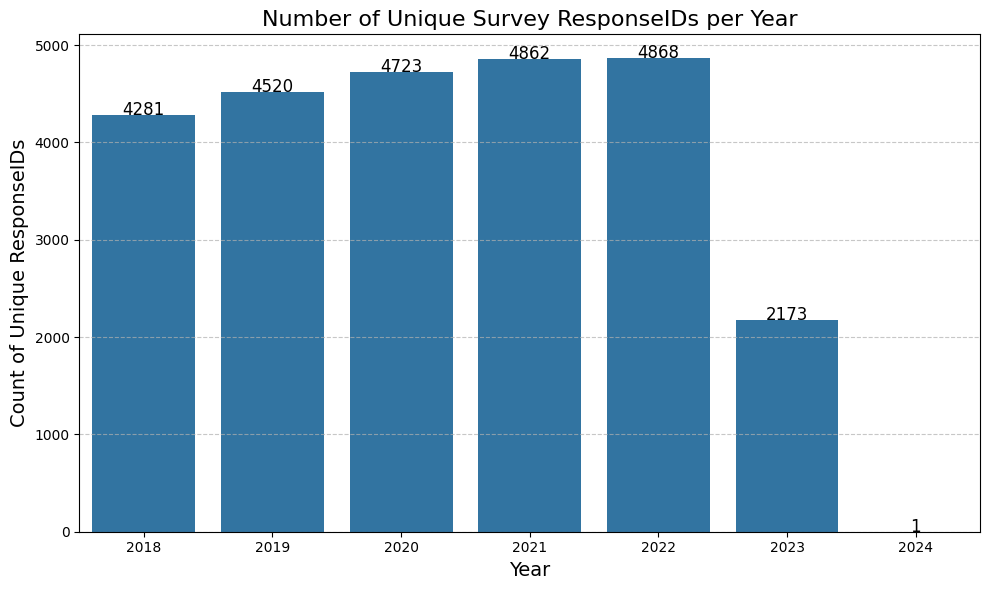

In [3]:
import seaborn as sns

amzn_sales = pd.read_csv("./data/amazon-purchases.csv")

amzn_sales.head()

amzn_sales['Order Date'] = pd.to_datetime(amzn_sales['Order Date'])

# Extract year from the date
amzn_sales['Year'] = amzn_sales['Order Date'].dt.year

# Count unique Survey ResponseIDs per year
yearly_counts = amzn_sales.groupby('Year')['Survey ResponseID'].nunique().reset_index()
yearly_counts.columns = ['Year', 'Unique ResponseIDs']

# Create the plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Year', y='Unique ResponseIDs', data=yearly_counts)

# Customize the plot
plt.title('Number of Unique Survey ResponseIDs per Year', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Count of Unique ResponseIDs', fontsize=14)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of each bar
for i, count in enumerate(yearly_counts['Unique ResponseIDs']):
    plt.text(i, count + 0.1, str(count), ha='center', fontsize=12)

plt.tight_layout()
plt.show()

# Stationarity test Fashion

In [4]:
fashion_df = fashion_df[(fashion_df['Order Date'] >= '2018-01-01')]

# Calculate the total revenue per each day
combined_fashion_df = fashion_df.groupby(["Order Date"]).agg({"Revenue": "sum"}).round(2)

print(combined_fashion_df.head())

            Revenue
Order Date         
2018-01-01   956.84
2018-01-02  1297.17
2018-01-03  1019.96
2018-01-04   956.76
2018-01-05   812.83


## Combined plot 

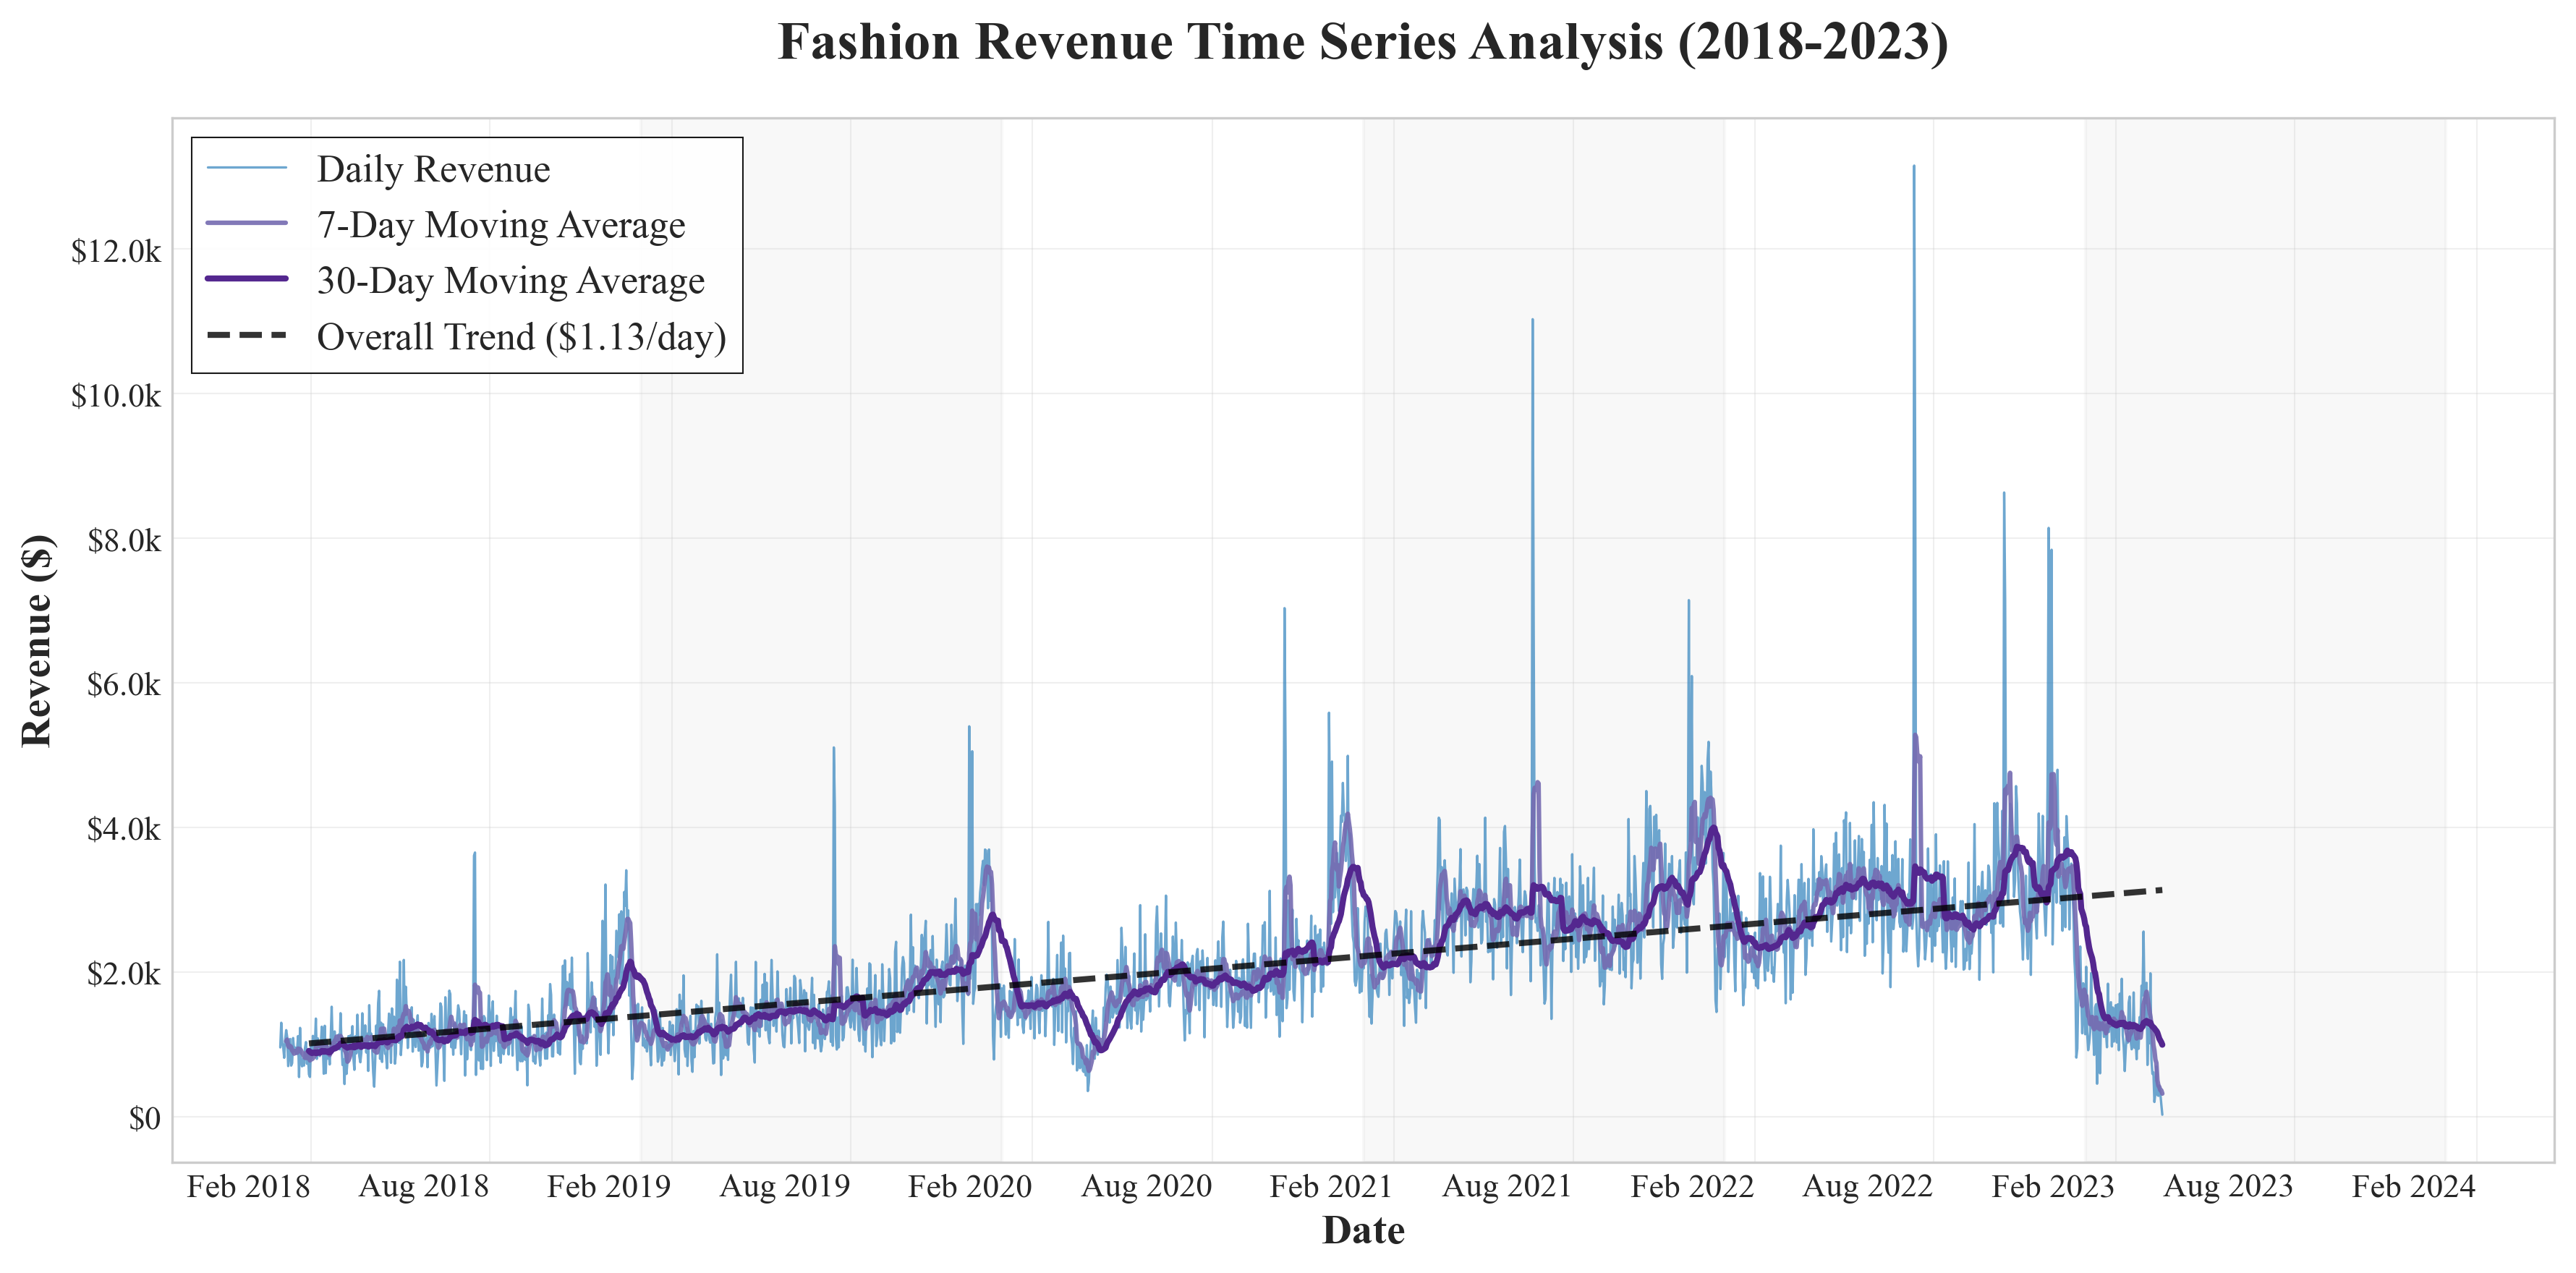


=== Combined Revenue Analysis Summary ===
Analysis Period: 2018-01-01 to 2023-03-20
Total Days: 1,905
Average Daily Revenue: $2,053.93
Daily Revenue Std Dev: $1,047.42
Revenue Growth Trend: $1.13 per day ($413 per year)

Volatility Analysis:
Daily Revenue Volatility: $1,047
7-Day MA Volatility: $868 (17.2% reduction)
30-Day MA Volatility: $795 (24.1% reduction)


In [5]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter

combined_fashion_df.index = pd.to_datetime(combined_fashion_df.index)

# Calculate SMA
combined_fashion_df['SMA7'] = combined_fashion_df['Revenue'].rolling(window=7).mean()
combined_fashion_df['SMA30'] = combined_fashion_df['Revenue'].rolling(window=30).mean()

# Function to format y-axis as $X.XXk
def currency_formatter(x, pos):
    if x >= 1000:
        return f'${x/1000:.1f}k'
    else:
        return f'${x:.0f}'

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Liberation Serif', 'DejaVu Serif'],
    'font.size': 11,
    'axes.linewidth': 0.8,
    'figure.dpi': 300
})

fig, ax = plt.subplots(figsize=(12, 6))

# Line 1: Daily Revenue 
ax.plot(combined_fashion_df.index, combined_fashion_df['Revenue'],
        color='#3182bd', alpha=0.7, linewidth=0.8, 
        label='Daily Revenue', zorder=1)

# Line 2: SMA7
ax.plot(combined_fashion_df.index, combined_fashion_df['SMA7'],
        color='#756bb1', linewidth=1.5, alpha=0.9,
        label='7-Day Moving Average', zorder=2)

# Line 3: SMA30
ax.plot(combined_fashion_df.index, combined_fashion_df['SMA30'],
        color='#54278f', linewidth=2.0, alpha=1.0,
        label='30-Day Moving Average', zorder=3)

# Add trend line based on 30-day moving average
x = np.arange(len(combined_fashion_df))

valid_data = combined_fashion_df['SMA30'].dropna()
valid_indices = x[29:]  # Start from index 29 to skip NaN values

z = np.polyfit(valid_indices, valid_data, 1)
p = np.poly1d(z)

# Trend line
ax.plot(combined_fashion_df.index[29:], p(valid_indices),
        "k--", linewidth=2, alpha=0.8, 
        label=f'Overall Trend (${z[0]:.2f}/day)', zorder=4)

ax.set_title('Fashion Revenue Time Series Analysis (2018-2023)', 
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=14, fontweight='bold')
ax.set_ylabel('Revenue ($)', fontsize=14, fontweight='bold')

ax.yaxis.set_major_formatter(FuncFormatter(currency_formatter))

ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

# Legend
legend = ax.legend(loc='upper left', fontsize=13, frameon=True, 
                  fancybox=False, shadow=False, framealpha=0.9,
                  edgecolor='black')

# Set legend frame linewidth separately
legend.get_frame().set_linewidth(0.5)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))  # Every 6 months
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))  # Minor ticks every 3 months

plt.setp(ax.xaxis.get_majorticklabels(), ha='right')

# Add background shading 
years = pd.date_range(start=combined_fashion_df.index.min(), 
                     end=combined_fashion_df.index.max(), freq='YS')
for i, year in enumerate(years[1:]): 
    if i % 2 == 0:  
        ax.axvspan(year, year + pd.DateOffset(years=1), 
                  alpha=0.05, color='gray', zorder=0)

plt.tight_layout()


plt.savefig('./Exports/combined_fashion_revenue_analysis.png', 
           dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()

# Optional summary information
print("\n=== Combined Revenue Analysis Summary ===")
print(f"Analysis Period: {combined_fashion_df.index.min().strftime('%Y-%m-%d')} to {combined_fashion_df.index.max().strftime('%Y-%m-%d')}")
print(f"Total Days: {len(combined_fashion_df):,}")
print(f"Average Daily Revenue: ${combined_fashion_df['Revenue'].mean():,.2f}")
print(f"Daily Revenue Std Dev: ${combined_fashion_df['Revenue'].std():,.2f}")
print(f"Revenue Growth Trend: ${z[0]:.2f} per day (${z[0]*365:.0f} per year)")

daily_volatility = combined_fashion_df['Revenue'].std()
sma7_volatility = combined_fashion_df['SMA7'].std()
sma30_volatility = combined_fashion_df['SMA30'].std()

print(f"\nVolatility Analysis:")
print(f"Daily Revenue Volatility: ${daily_volatility:,.0f}")
print(f"7-Day MA Volatility: ${sma7_volatility:,.0f} ({(1-sma7_volatility/daily_volatility)*100:.1f}% reduction)")
print(f"30-Day MA Volatility: ${sma30_volatility:,.0f} ({(1-sma30_volatility/daily_volatility)*100:.1f}% reduction)")

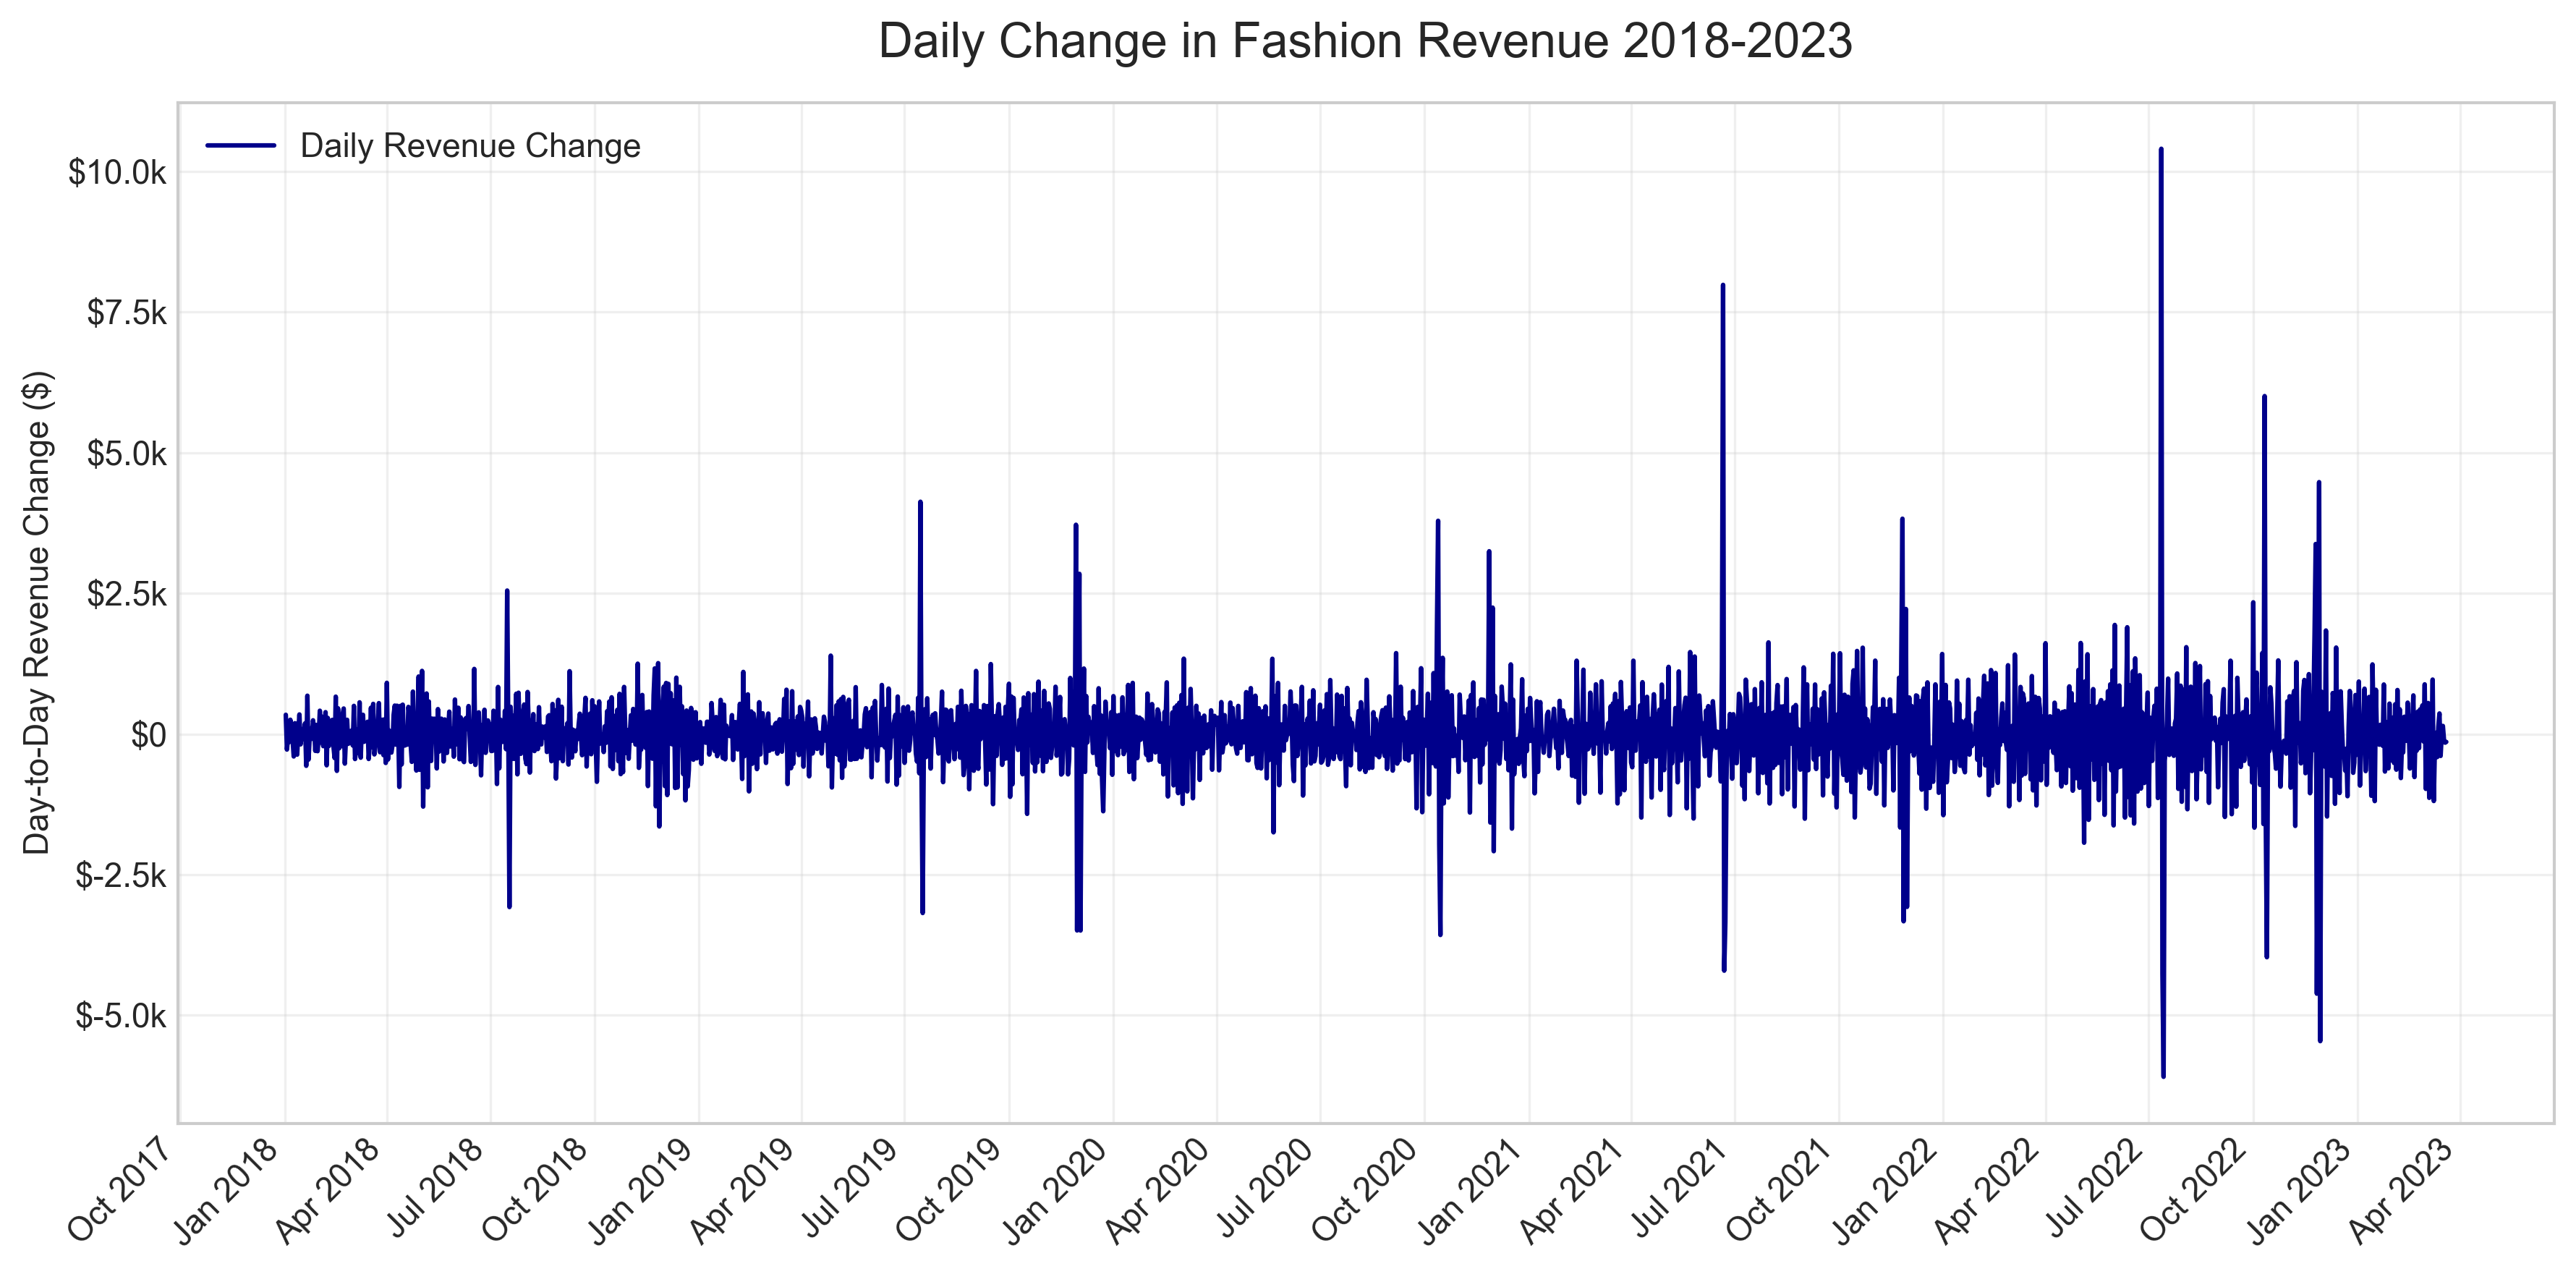

In [6]:
combined_fashion_df.index = pd.to_datetime(combined_fashion_df.index)

combined_fashion_df['Revenue_Diff'] = combined_fashion_df['Revenue'].diff()

# Function to format y-axis as $X.XXk
def currency_formatter(x, pos):
    if abs(x) >= 1000:
        return f'${x/1000:.1f}k'
    else:
        return f'${x:.0f}'

plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(12, 6)) 

# Add first-order difference
ax.plot(combined_fashion_df.index[1:], combined_fashion_df['Revenue_Diff'].iloc[1:], 
        color='darkblue', alpha=1, linewidth=1.5, label='Daily Revenue Change')


ax.set_title('Daily Change in Fashion Revenue 2018-2023', fontsize=16, pad=15)
ax.set_ylabel('Day-to-Day Revenue Change ($)')
ax.yaxis.set_major_formatter(FuncFormatter(currency_formatter))
ax.grid(True, alpha=0.3)

ax.legend(loc='best')

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Augmented Dickey-Fuller (ADF) test

In [7]:
ADF_df = combined_fashion_df.iloc[29:,] # Adjust df because of null values resulting from SMA30

In [8]:
# Revenue -> Stationary
adf_result = adfuller(ADF_df["Revenue"])

print(f'p-value Revenue: {adf_result[1]}')

# SMA7 -> Stationary
adf_result = adfuller(ADF_df["SMA7"])
print(f'p-value SMA7: {adf_result[1]}')

# SMA30 -> Not Stationary
adf_result = adfuller(ADF_df["SMA30"])
print(f'p-value SMA30: {adf_result[1]}')


# SMA30 -> Not Stationary
adf_result = adfuller(ADF_df["Revenue_Diff"])
print(f'p-value First order difference: {adf_result[1]}')

p-value Revenue: 0.009760838786308871
p-value SMA7: 0.043099306720730576
p-value SMA30: 0.20128268155517337
p-value First order difference: 1.0055800944183514e-25


# Stationarity tests Grocieries

In [9]:
grocery_df = grocery_df[(grocery_df['Order Date'] >= '2018-01-01')]

# Calculate the total revenue per each day
combined_grocery_df = grocery_df.groupby(["Order Date"]).agg({"Revenue": "sum"}).round(2)

combined_grocery_df.head()

,Revenue
Order Date,
2018-01-01,409.89
2018-01-02,670.35
2018-01-03,472.03
2018-01-04,358.15
2018-01-05,441.39


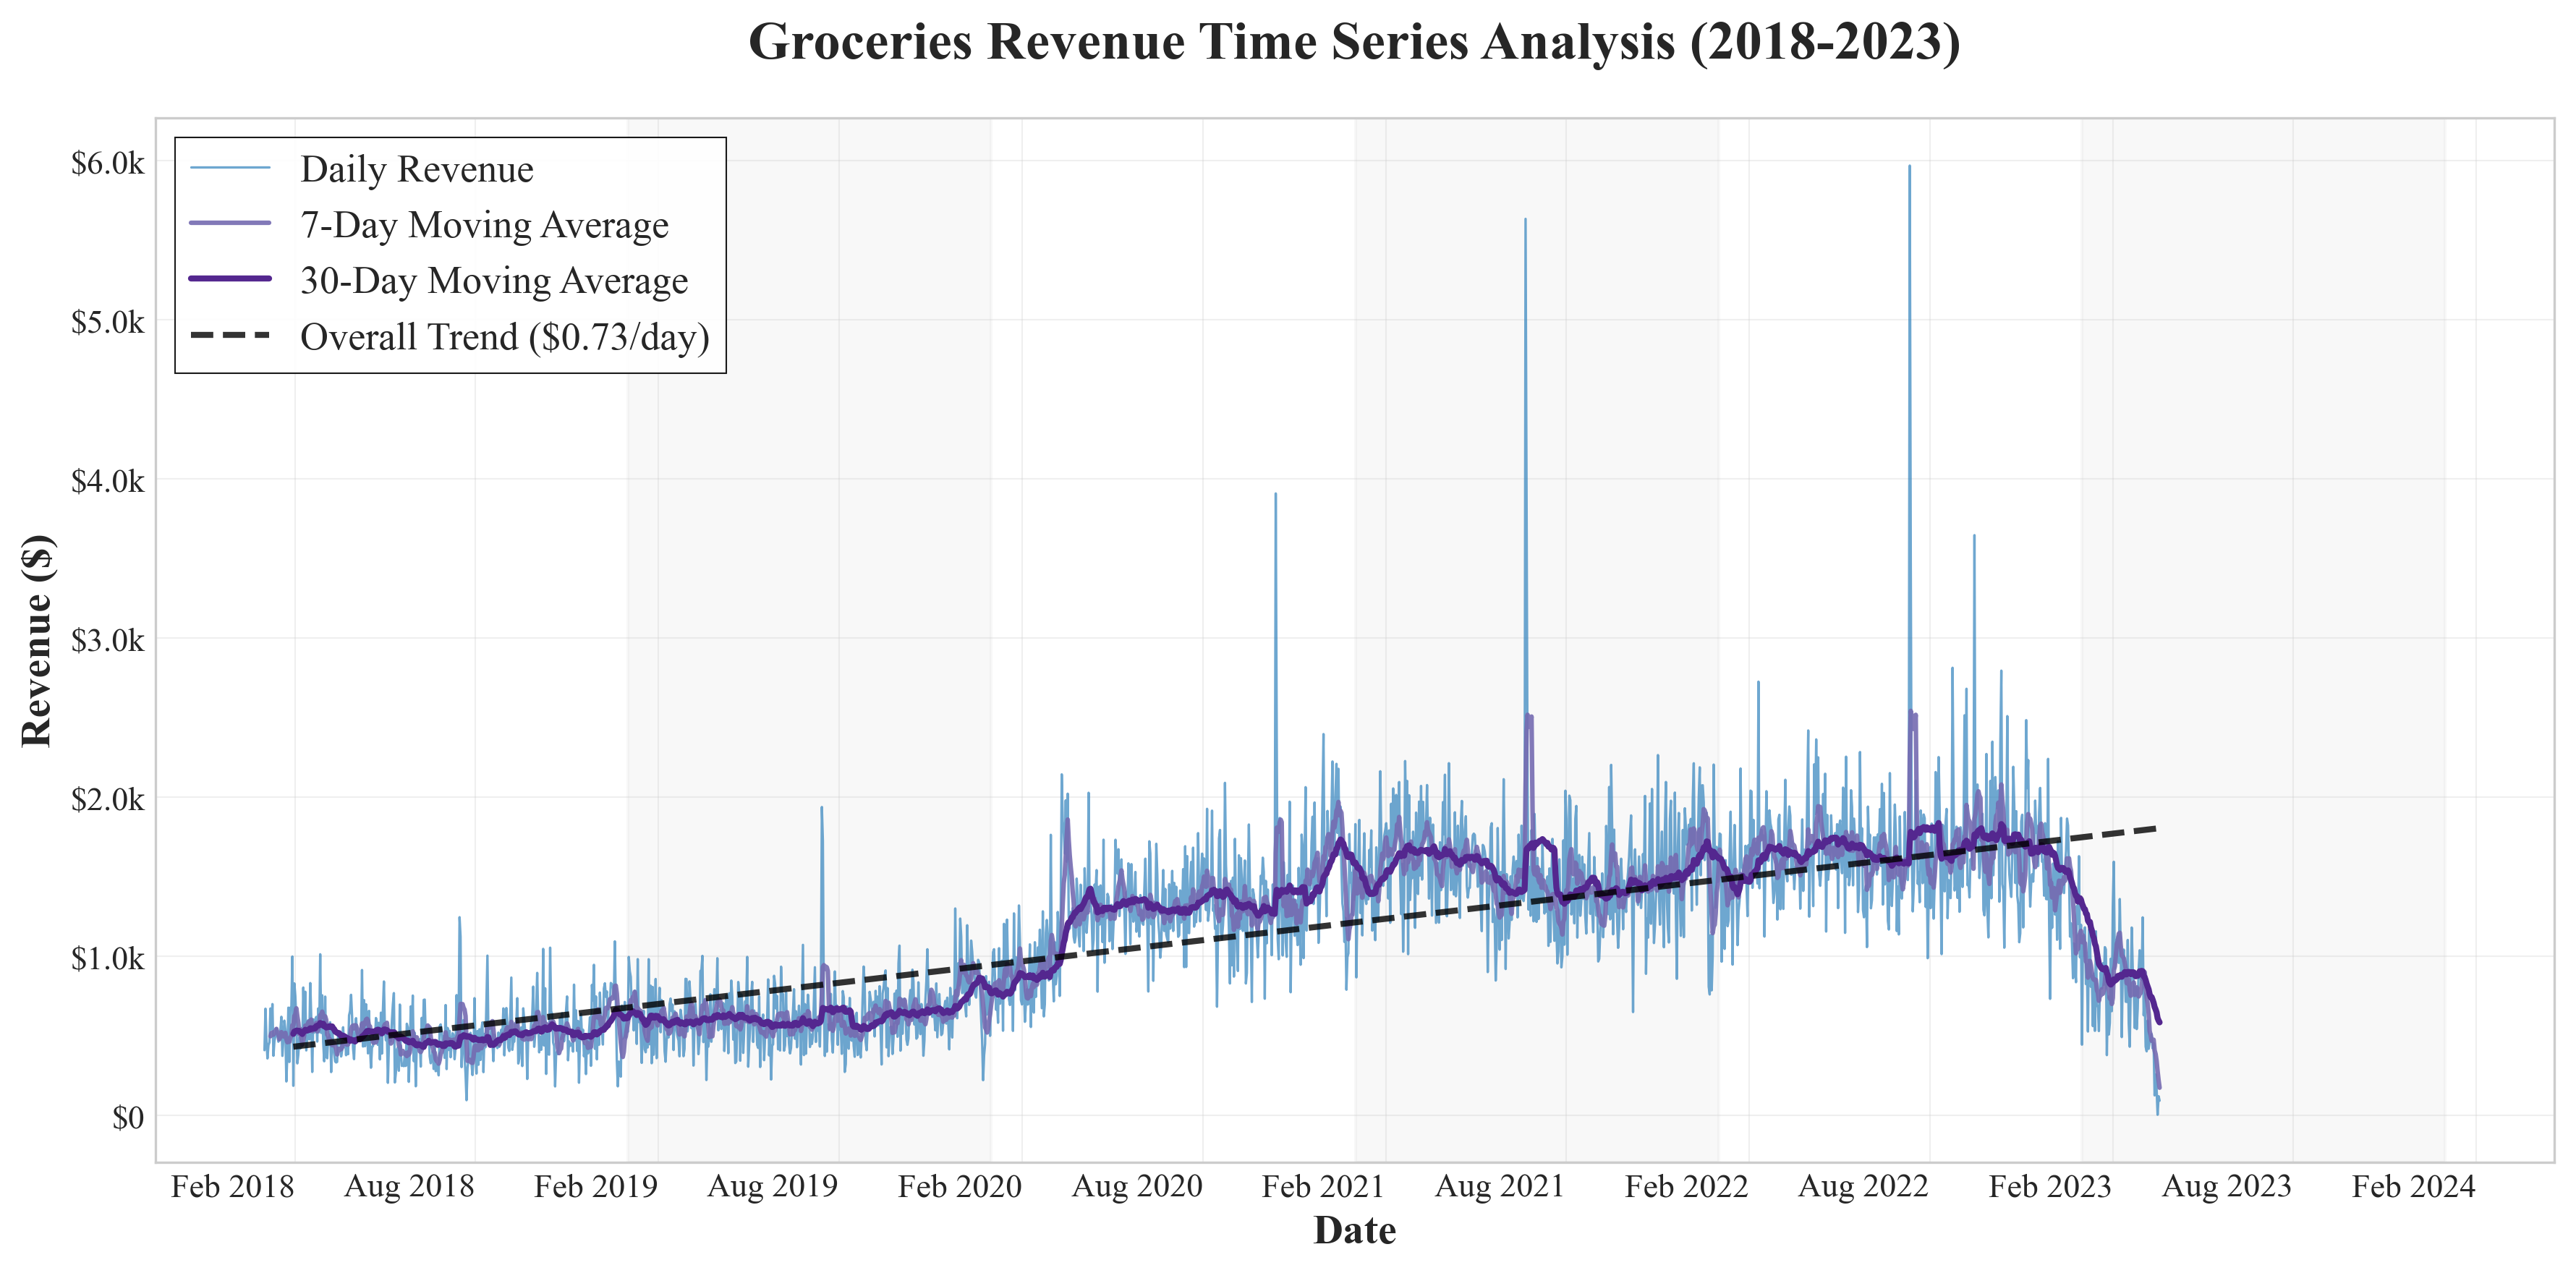


=== Combined Revenue Analysis Summary ===
Analysis Period: 2018-01-01 to 2023-03-20
Total Days: 1,905
Average Daily Revenue: $1,108.55
Daily Revenue Std Dev: $567.13
Revenue Growth Trend: $0.73 per day ($267 per year)

Volatility Analysis:
Daily Revenue Volatility: $567
7-Day MA Volatility: $493 (13.1% reduction)
30-Day MA Volatility: $474 (16.5% reduction)


In [10]:

combined_grocery_df.index = pd.to_datetime(combined_grocery_df.index)

# Calculate SMA
combined_grocery_df['SMA7'] = combined_grocery_df['Revenue'].rolling(window=7).mean()
combined_grocery_df['SMA30'] = combined_grocery_df['Revenue'].rolling(window=30).mean()

# Function to format y-axis as $X.XXk
def currency_formatter(x, pos):
    if x >= 1000:
        return f'${x/1000:.1f}k'
    else:
        return f'${x:.0f}'

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Liberation Serif', 'DejaVu Serif'],
    'font.size': 11,
    'axes.linewidth': 0.8,
    'figure.dpi': 300
})

fig, ax = plt.subplots(figsize=(12, 6))

# Line 1: Daily Revenue 
ax.plot(combined_grocery_df.index, combined_grocery_df['Revenue'],
        color='#3182bd', alpha=0.7, linewidth=0.8, 
        label='Daily Revenue', zorder=1)

# Line 2: SMA7
ax.plot(combined_grocery_df.index, combined_grocery_df['SMA7'],
        color='#756bb1', linewidth=1.5, alpha=0.9,
        label='7-Day Moving Average', zorder=2)

# Line 3: SMA30
ax.plot(combined_grocery_df.index, combined_grocery_df['SMA30'],
        color='#54278f', linewidth=2.0, alpha=1.0,
        label='30-Day Moving Average', zorder=3)

# Add trend line
x = np.arange(len(combined_grocery_df))
valid_data = combined_grocery_df['SMA30'].dropna()
valid_indices = x[29:]  # Start from index 29 to skip NaN values

z = np.polyfit(valid_indices, valid_data, 1)
p = np.poly1d(z)

ax.plot(combined_grocery_df.index[29:], p(valid_indices),
        "k--", linewidth=2, alpha=0.8, 
        label=f'Overall Trend (${z[0]:.2f}/day)', zorder=4)


ax.set_title('Groceries Revenue Time Series Analysis (2018-2023)', 
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=14, fontweight='bold')
ax.set_ylabel('Revenue ($)', fontsize=14, fontweight='bold')

ax.yaxis.set_major_formatter(FuncFormatter(currency_formatter))


ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

legend = ax.legend(loc='upper left', fontsize=13, frameon=True, 
                  fancybox=False, shadow=False, framealpha=0.9,
                  edgecolor='black')

legend.get_frame().set_linewidth(0.5)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))  

plt.setp(ax.xaxis.get_majorticklabels(), ha='right')

# Add background shading for different years 
years = pd.date_range(start=combined_grocery_df.index.min(), 
                     end=combined_grocery_df.index.max(), freq='YS')
for i, year in enumerate(years[1:]): 
    if i % 2 == 0:  
        ax.axvspan(year, year + pd.DateOffset(years=1), 
                  alpha=0.05, color='gray', zorder=0)

plt.tight_layout()


# Save the plot
plt.savefig('./Exports/combined_groceries_revenue_analysis.png', 
           dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()

# Optional summary information
print("\n=== Combined Revenue Analysis Summary ===")
print(f"Analysis Period: {combined_grocery_df.index.min().strftime('%Y-%m-%d')} to {combined_grocery_df.index.max().strftime('%Y-%m-%d')}")
print(f"Total Days: {len(combined_grocery_df):,}")
print(f"Average Daily Revenue: ${combined_grocery_df['Revenue'].mean():,.2f}")
print(f"Daily Revenue Std Dev: ${combined_grocery_df['Revenue'].std():,.2f}")
print(f"Revenue Growth Trend: ${z[0]:.2f} per day (${z[0]*365:.0f} per year)")

daily_volatility = combined_grocery_df['Revenue'].std()
sma7_volatility = combined_grocery_df['SMA7'].std()
sma30_volatility = combined_grocery_df['SMA30'].std()

print(f"\nVolatility Analysis:")
print(f"Daily Revenue Volatility: ${daily_volatility:,.0f}")
print(f"7-Day MA Volatility: ${sma7_volatility:,.0f} ({(1-sma7_volatility/daily_volatility)*100:.1f}% reduction)")
print(f"30-Day MA Volatility: ${sma30_volatility:,.0f} ({(1-sma30_volatility/daily_volatility)*100:.1f}% reduction)")

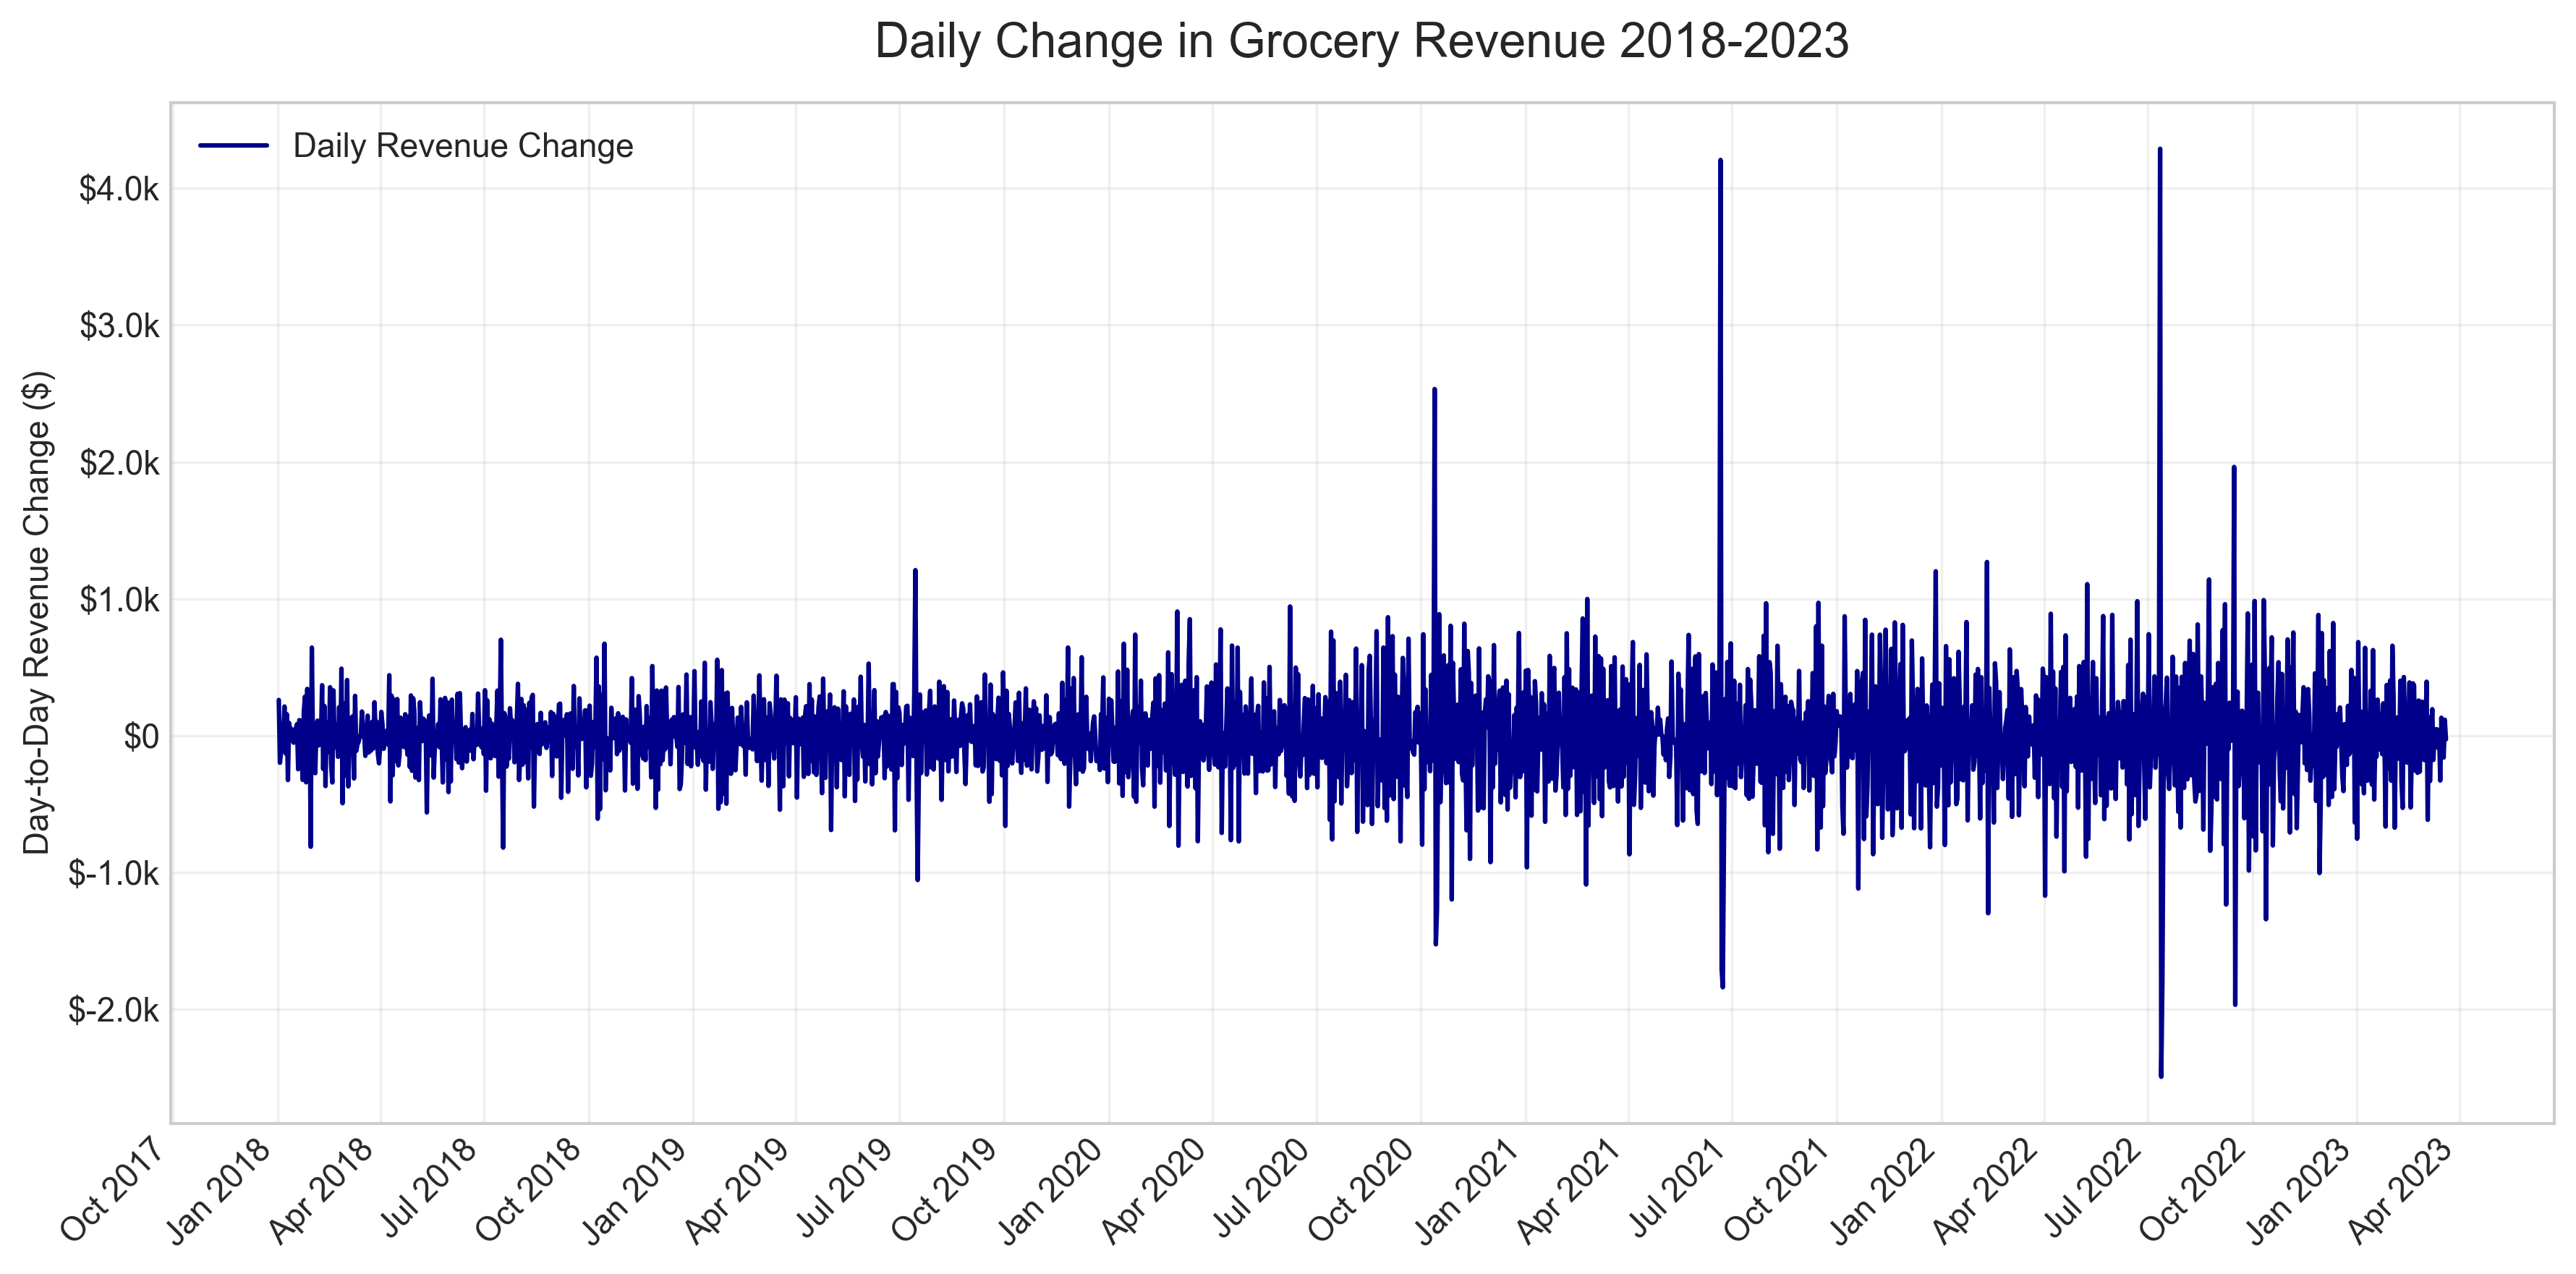

In [11]:

combined_grocery_df.index = pd.to_datetime(combined_grocery_df.index)

# Calculate the first-order difference of revenue
combined_grocery_df['Revenue_Diff'] = combined_grocery_df['Revenue'].diff()

# Function to format y-axis as $X.XXk
def currency_formatter(x, pos):
    if abs(x) >= 1000:
        return f'${x/1000:.1f}k'
    else:
        return f'${x:.0f}'

plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(12, 6)) 

# Add first-order difference
ax.plot(combined_grocery_df.index[1:], combined_grocery_df['Revenue_Diff'].iloc[1:], 
        color='darkblue', alpha=1, linewidth=1.5, label='Daily Revenue Change')


ax.set_title('Daily Change in Grocery Revenue 2018-2023', fontsize=16, pad=15)
ax.set_ylabel('Day-to-Day Revenue Change ($)')
ax.yaxis.set_major_formatter(FuncFormatter(currency_formatter))
ax.grid(True, alpha=0.3)

ax.legend(loc='best')

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Augmented Dickey-Fuller (ADF) test

In [12]:
ADF_df = combined_grocery_df.iloc[29:,] # Adjust df because of null values resulting from SMA30

In [13]:
# Revenue -> Stationary
adf_result = adfuller(ADF_df["Revenue"])
print(f'p-value Revenue: {adf_result[1]}')

# SMA7 -> Stationary
adf_result = adfuller(ADF_df["SMA7"])
print(f'p-value SMA7: {adf_result[1]}')

# SMA30 -> Not Stationary
adf_result = adfuller(ADF_df["SMA30"])
print(f'p-value SMA30: {adf_result[1]}')

# SMA30 -> Not Stationary
adf_result = adfuller(ADF_df["Revenue_Diff"])
print(f'p-value SMA30: {adf_result[1]}')

p-value Revenue: 0.5595820038273827
p-value SMA7: 0.6680244493141386
p-value SMA30: 0.6461628454627977
p-value SMA30: 1.1911511146944316e-24


# Seasonality in Temperature

In [14]:
weather = pd.read_csv("./data/weather_data.csv")
print(weather.head())

   Unnamed: 0 st_abb  st_code      date stability     ppt    tmax    tmin  \
0           1     AL        1  20170101    stable  25.626  13.849   4.712   
1           2     AL        1  20170102    stable  40.827  17.970  12.968   
2           3     AL        1  20170103    stable  54.893  19.500  13.828   
3           4     AL        1  20170104    stable   0.048  19.158   8.744   
4           5     AL        1  20170105    stable   0.002  11.202  -0.147   

     tavg  dday_a0C  ...  dday_a25C  dday_a29C  dday_a30C  dday_a31C  \
0   9.280     9.280  ...      0.000        0.0        0.0        0.0   
1  15.469    15.469  ...      0.000        0.0        0.0        0.0   
2  16.664    16.665  ...      0.001        0.0        0.0        0.0   
3  13.951    13.951  ...      0.000        0.0        0.0        0.0   
4   5.527     5.714  ...      0.000        0.0        0.0        0.0   

   dday_a32C  dday_a33C  dday_a34C  dday_b15C  dday_b18C  dday_b21C  
0        0.0        0.0        0.0

In [15]:
weather['date'] = pd.to_datetime(weather['date'], format='%Y%m%d')

C:\Users\Moritz\AppData\Local\Temp\ipykernel_26028\3697667563.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])


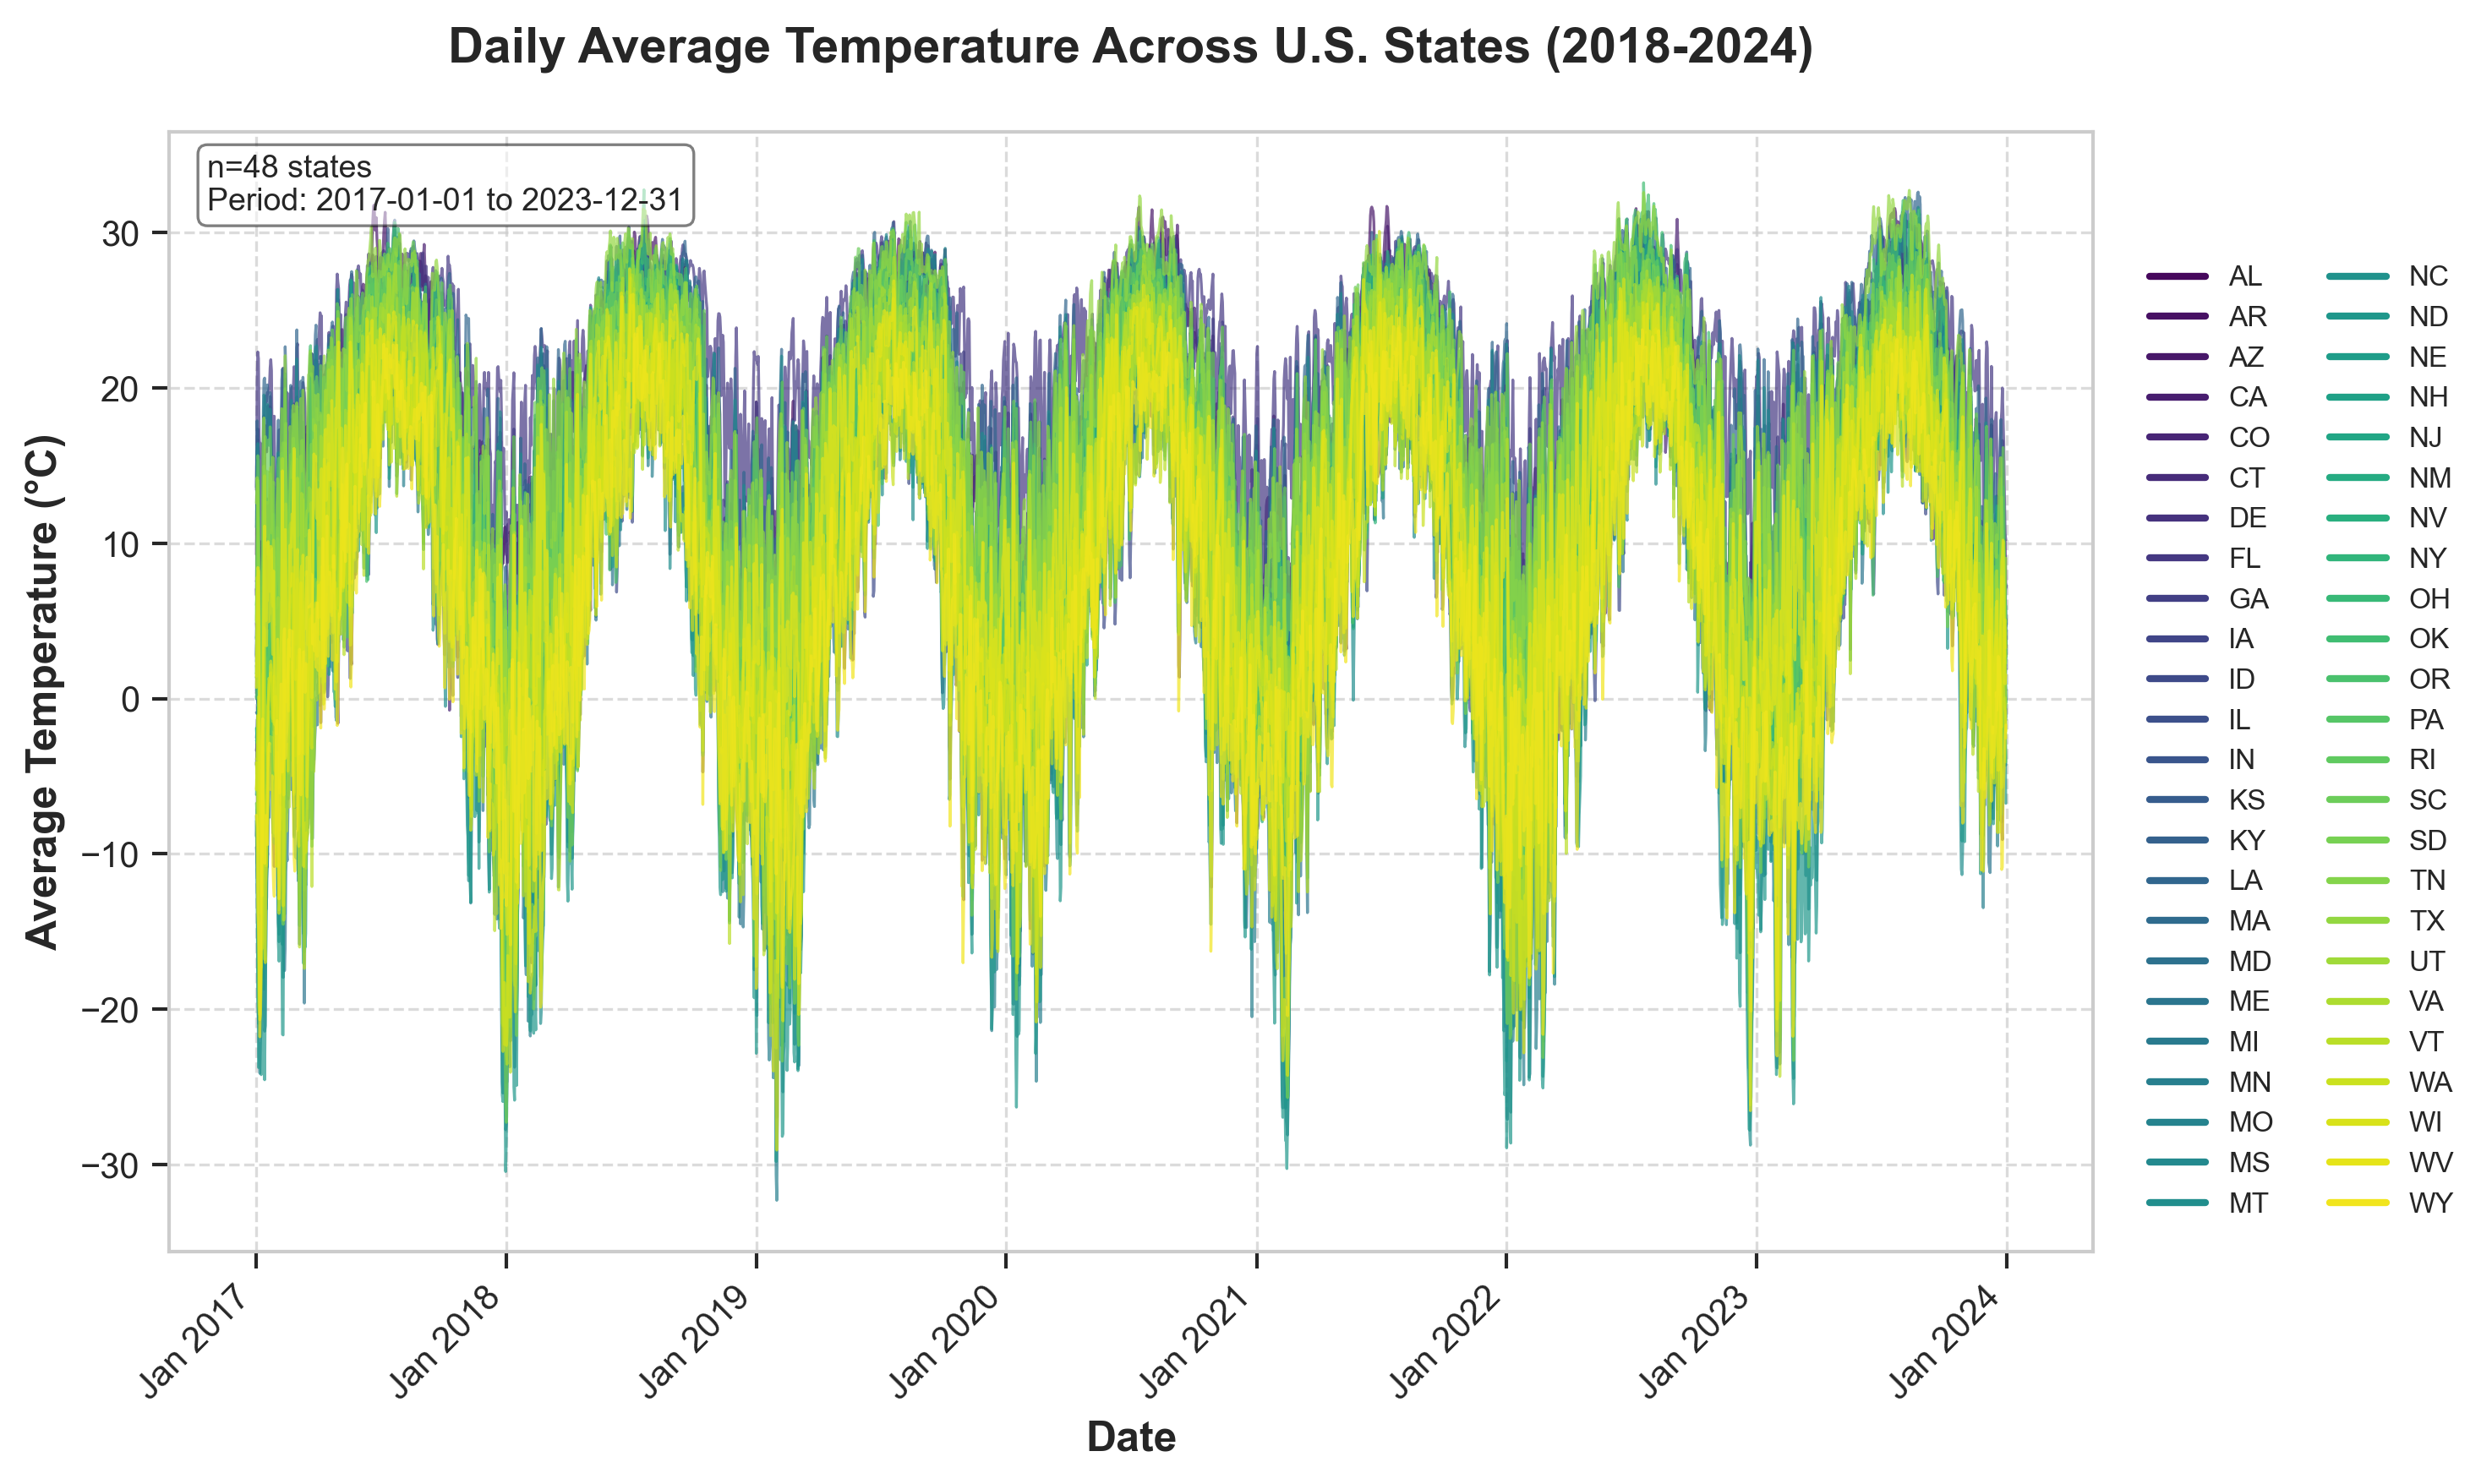

In [16]:
sns.set_context("paper", font_scale=1.2)

fig = plt.figure(figsize=(10, 6), dpi=300)
gs = GridSpec(1, 1, figure=fig)
ax = fig.add_subplot(gs[0, 0])

# Get a list of unique states
states = weather['st_abb'].unique()

# Calculate the mean temperature for each state on each date
state_temp_by_date = weather.pivot_table(index='date', columns='st_abb', values='tavg', aggfunc='mean')

palette = sns.color_palette("viridis", len(states))

# Plot each state's temperature over time
for i, state in enumerate(states):
    ax.plot(state_temp_by_date.index, state_temp_by_date[state], 
            color=palette[i], linewidth=0.8, alpha=0.7)


legend_ax = fig.add_axes([0.85, 0.15, 0.13, 0.7])  # [left, bottom, width, height]
legend_ax.axis('off')

# Add state names to legend in alphabetical order with colored markers
for i, state in enumerate(sorted(states)):
    legend_ax.plot([0], [0], color=palette[list(states).index(state)], linewidth=2, label=state)

legend_ax.legend(loc='center', frameon=False, fontsize=8, ncol=2)

ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Temperature (°C)', fontsize=12, fontweight='bold')
ax.xaxis.set_major_formatter(DateFormatter('%b %Y'))
ax.tick_params(axis='both', labelsize=10)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

ax.grid(True, linestyle='--', alpha=0.7)

ax.set_title('Daily Average Temperature Across U.S. States (2018-2024)', 
            fontsize=14, fontweight='bold', pad=20)

# Add statistical information
text_str = f'n={len(states)} states\nPeriod: {weather.date.min().strftime("%Y-%m-%d")} to {weather.date.max().strftime("%Y-%m-%d")}'
props = dict(boxstyle='round', facecolor='white', alpha=0.5)
ax.text(0.02, 0.98, text_str, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=props)


plt.tight_layout(rect=[0, 0, 0.85, 1])

plt.savefig('./Exports/us_state_temperatures.png', dpi=300, bbox_inches='tight')

plt.show()

C:\Users\Moritz\AppData\Local\Temp\ipykernel_26028\951020489.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])


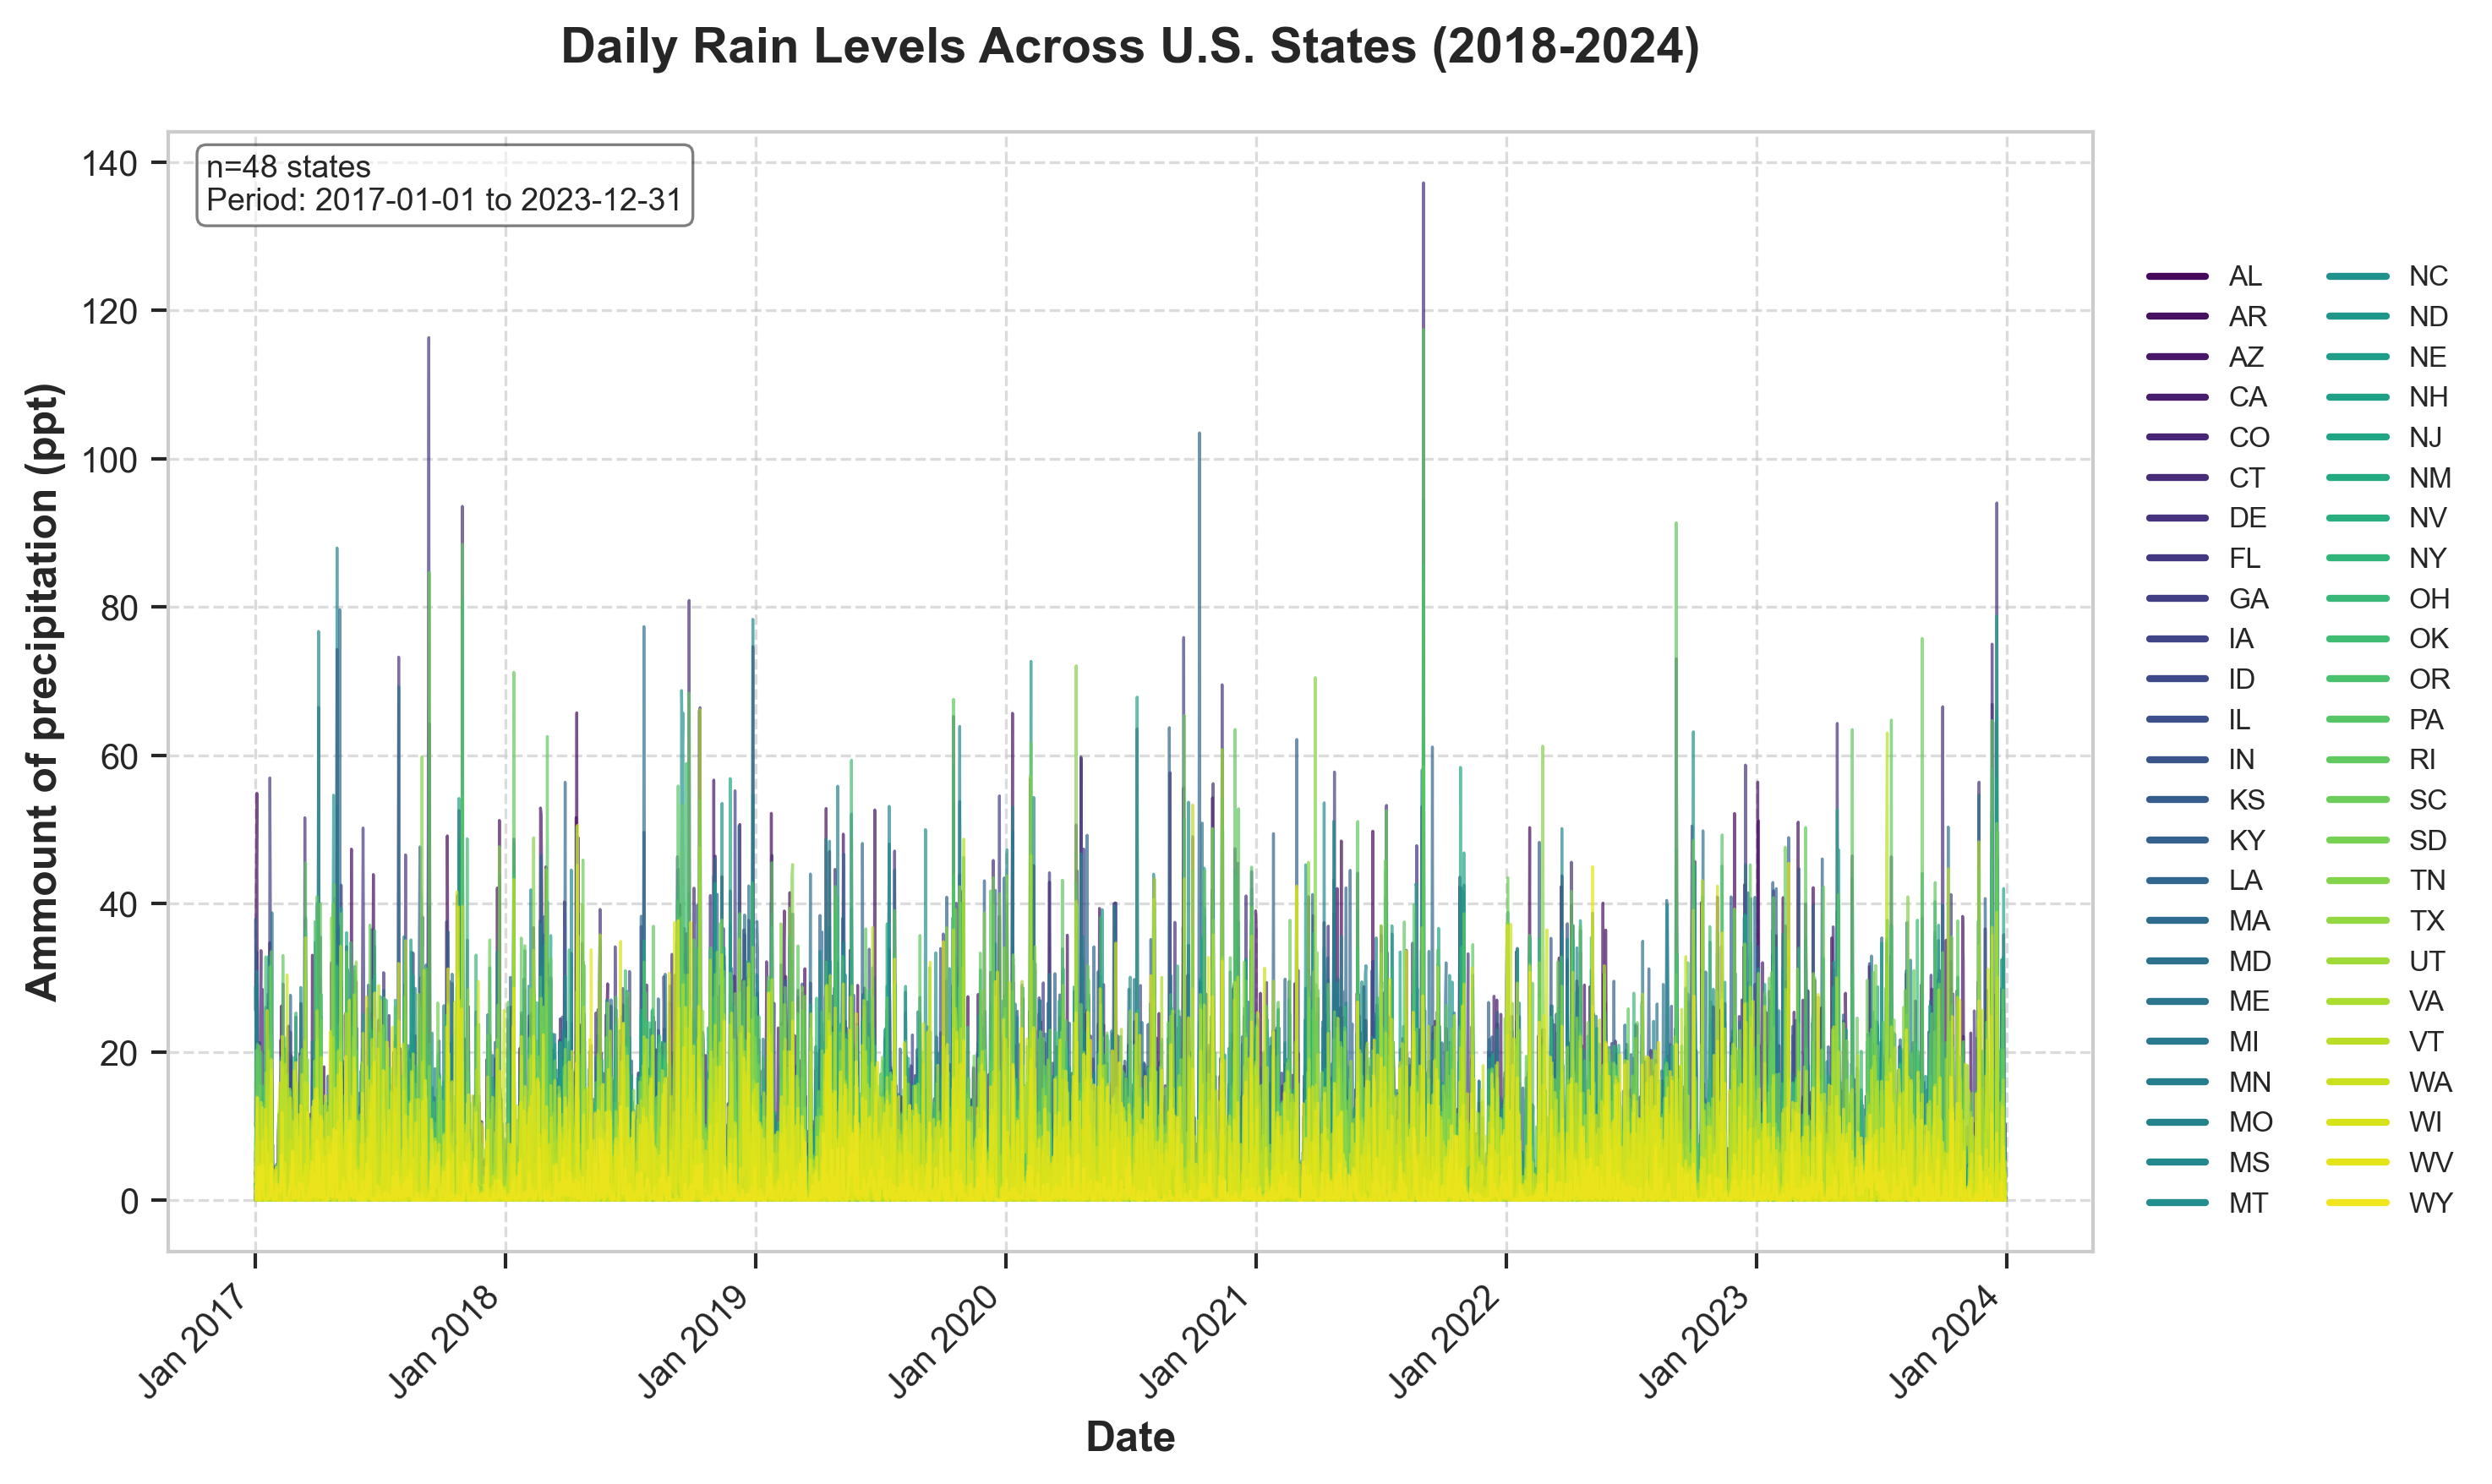

In [18]:
sns.set_context("paper", font_scale=1.2)

fig = plt.figure(figsize=(10, 6), dpi=300)
gs = GridSpec(1, 1, figure=fig)
ax = fig.add_subplot(gs[0, 0])

# Get a list of unique states
states = weather['st_abb'].unique()

# Calculate mean temperature for each state on each date
state_temp_by_date = weather.pivot_table(index='date', columns='st_abb', values='ppt', aggfunc='mean')

palette = sns.color_palette("viridis", len(states))

# Plot each state's temperature over time
for i, state in enumerate(states):
    ax.plot(state_temp_by_date.index, state_temp_by_date[state], 
            color=palette[i], linewidth=0.8, alpha=0.7)

legend_ax = fig.add_axes([0.85, 0.15, 0.13, 0.7])  # [left, bottom, width, height]
legend_ax.axis('off')

# Add state names to legend in alphabetical order with colored markers
for i, state in enumerate(sorted(states)):
    legend_ax.plot([0], [0], color=palette[list(states).index(state)], linewidth=2, label=state)

legend_ax.legend(loc='center', frameon=False, fontsize=8, ncol=2)

ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Ammount of precipitation (ppt)', fontsize=12, fontweight='bold')
ax.xaxis.set_major_formatter(DateFormatter('%b %Y'))
ax.tick_params(axis='both', labelsize=10)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# Add grid
ax.grid(True, linestyle='--', alpha=0.7)

ax.set_title('Daily Rain Levels Across U.S. States (2018-2024)', 
            fontsize=14, fontweight='bold', pad=20)

# Add statistical information
text_str = f'n={len(states)} states\nPeriod: {weather.date.min().strftime("%Y-%m-%d")} to {weather.date.max().strftime("%Y-%m-%d")}'
props = dict(boxstyle='round', facecolor='white', alpha=0.5)
ax.text(0.02, 0.98, text_str, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=props)


plt.tight_layout(rect=[0, 0, 0.85, 1])

plt.savefig('./Exports/us_state_rain.png', dpi=300, bbox_inches='tight')

plt.show()

# Single State (CA)

In [19]:
fashion_CA = fashion_df[fashion_df['Shipping Address State'] == "CA"]
fashion_CA = fashion_CA[["Order Date", "Revenue"]]
grocery_CA = grocery_df[grocery_df['Shipping Address State'] == "CA"]
grocery_CA = grocery_CA[["Order Date", "Revenue"]]


### Visual Analysis

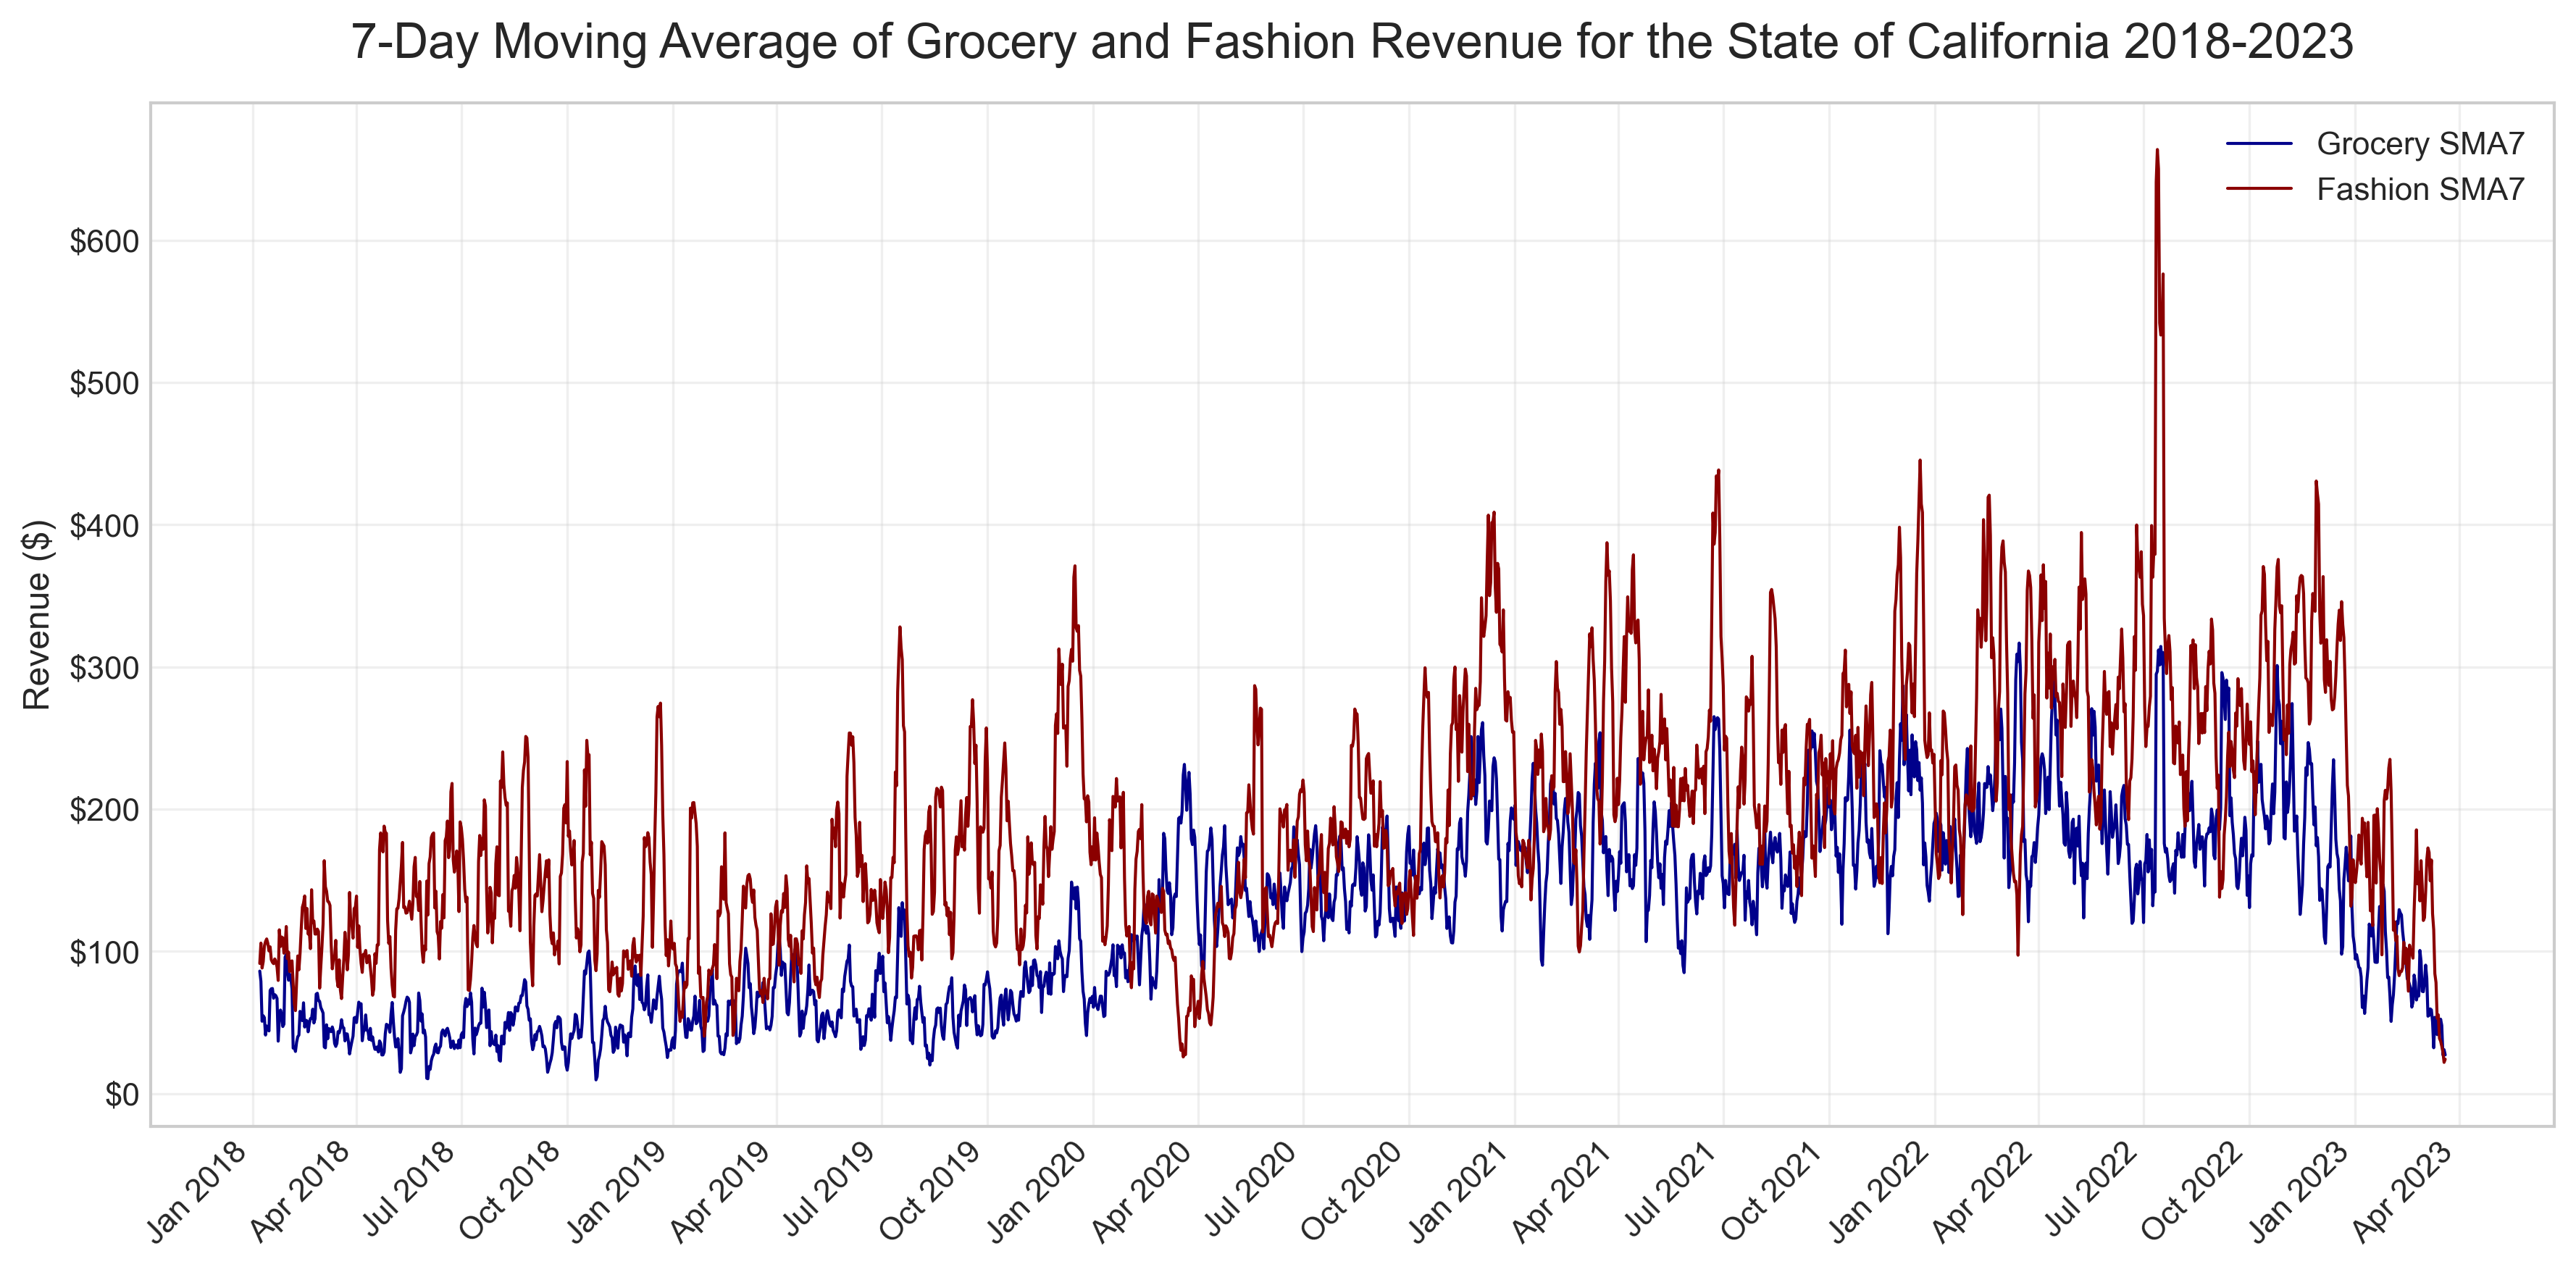

In [20]:

combined_grocery_df = grocery_CA.copy()
combined_fashion_df = fashion_CA.copy()

combined_grocery_df.index = pd.to_datetime(grocery_CA["Order Date"])
combined_fashion_df.index = pd.to_datetime(fashion_CA["Order Date"])


# Calculate the 7-day Simple Moving Average
combined_grocery_df['SMA7'] = combined_grocery_df['Revenue'].rolling(window=7).mean()
combined_fashion_df['SMA7'] = combined_fashion_df['Revenue'].rolling(window=7).mean()

# Calcualte SMA30 
combined_grocery_df['SMA30'] = combined_grocery_df['Revenue'].rolling(window=30).mean()
combined_fashion_df['SMA30'] = combined_fashion_df['Revenue'].rolling(window=30).mean()

# Calucalte firsto order difference
combined_fashion_df['Revenue_Diff'] = combined_fashion_df['Revenue'].diff()
combined_grocery_df['Revenue_Diff'] = combined_grocery_df['Revenue'].diff()


# Function to format y-axis as $X.XXk
def currency_formatter(x, pos):
    if x >= 1000:
        return f'${x/1000:.1f}k'
    else:
        return f'${x:.0f}'

plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(12, 6)) 

# Plot 7-day SMA
ax.plot(combined_grocery_df.index, combined_grocery_df['SMA7'], 
        color='darkblue', linewidth=1, alpha=1,label='Grocery SMA7')

ax.plot(combined_fashion_df.index, combined_fashion_df['SMA7'], 
        color='darkred', linewidth=1, alpha=1,label='Fashion SMA7')

ax.set_title('7-Day Moving Average of Grocery and Fashion Revenue for the State of California 2018-2023', fontsize=16, pad=15)
ax.set_ylabel('Revenue ($)')
ax.yaxis.set_major_formatter(FuncFormatter(currency_formatter))
ax.grid(True, alpha=0.3)


ax.legend(loc='best')


ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

## ADF Test

### Fashion

In [21]:
ADF_df = combined_fashion_df.iloc[29:,] # Adjust df because of null values resulting from SMA30

In [22]:
# Revenue -> Stationary
adf_result = adfuller(ADF_df["Revenue"])

print(f'p-value Revenue: {adf_result[1]}')

# SMA7 -> Stationary
adf_result = adfuller(ADF_df["SMA7"])
print(f'p-value SMA7: {adf_result[1]}')

# SMA30 -> Not Stationary
adf_result = adfuller(ADF_df["SMA30"])
print(f'p-value SMA30: {adf_result[1]}')


# SMA30 -> Not Stationary
adf_result = adfuller(ADF_df["Revenue_Diff"])
print(f'p-value First order difference: {adf_result[1]}')

p-value Revenue: 0.00023753670907228824
p-value SMA7: 0.006140366691819917
p-value SMA30: 0.017713466289914458
p-value First order difference: 5.8631717520802035e-28


### Grocery

In [23]:
ADF_df = combined_grocery_df.iloc[29:,] # Adjust df because of null values resulting from SMA30

In [24]:
# Revenue -> Stationary
adf_result = adfuller(ADF_df["Revenue"])

print(f'p-value Revenue: {adf_result[1]}')

# SMA7 -> Stationary
adf_result = adfuller(ADF_df["SMA7"])
print(f'p-value SMA7: {adf_result[1]}')

# SMA30 -> Not Stationary
adf_result = adfuller(ADF_df["SMA30"])
print(f'p-value SMA30: {adf_result[1]}')


# SMA30 -> Not Stationary
adf_result = adfuller(ADF_df["Revenue_Diff"])
print(f'p-value First order difference: {adf_result[1]}')

p-value Revenue: 0.186617638738016
p-value SMA7: 0.3325225814797031
p-value SMA30: 0.580312824020623
p-value First order difference: 6.410157256171119e-26


# Adjusting the trend for Temperature
Note: This part has been done in the 0_Data_Processing File to keep data processing operations in one central location. <br>
For further information please refer to Creating trend free temperature on a state level in the 0_Data_Processing File.

# LEGACY CODE (CAN BE REMOVED BEFORE SUBMISSION)

In [25]:
# Multiplicative Decomposition 
multiplicative_decomposition = seasonal_decompose(combined_grocery_df["Revenue"], model='multiplicative', period=30)

# Additive Decomposition
additive_decomposition = seasonal_decompose(combined_grocery_df["Revenue"], model='additive', period=30)

# Plot
plt.rcParams.update({'figure.figsize': (16,12)})
multiplicative_decomposition.plot().suptitle('Multiplicative Decomposition period = 30', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

additive_decomposition.plot().suptitle('Additive Decomposition period = 30', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()

ValueError: Multiplicative seasonality is not appropriate for zero and negative values

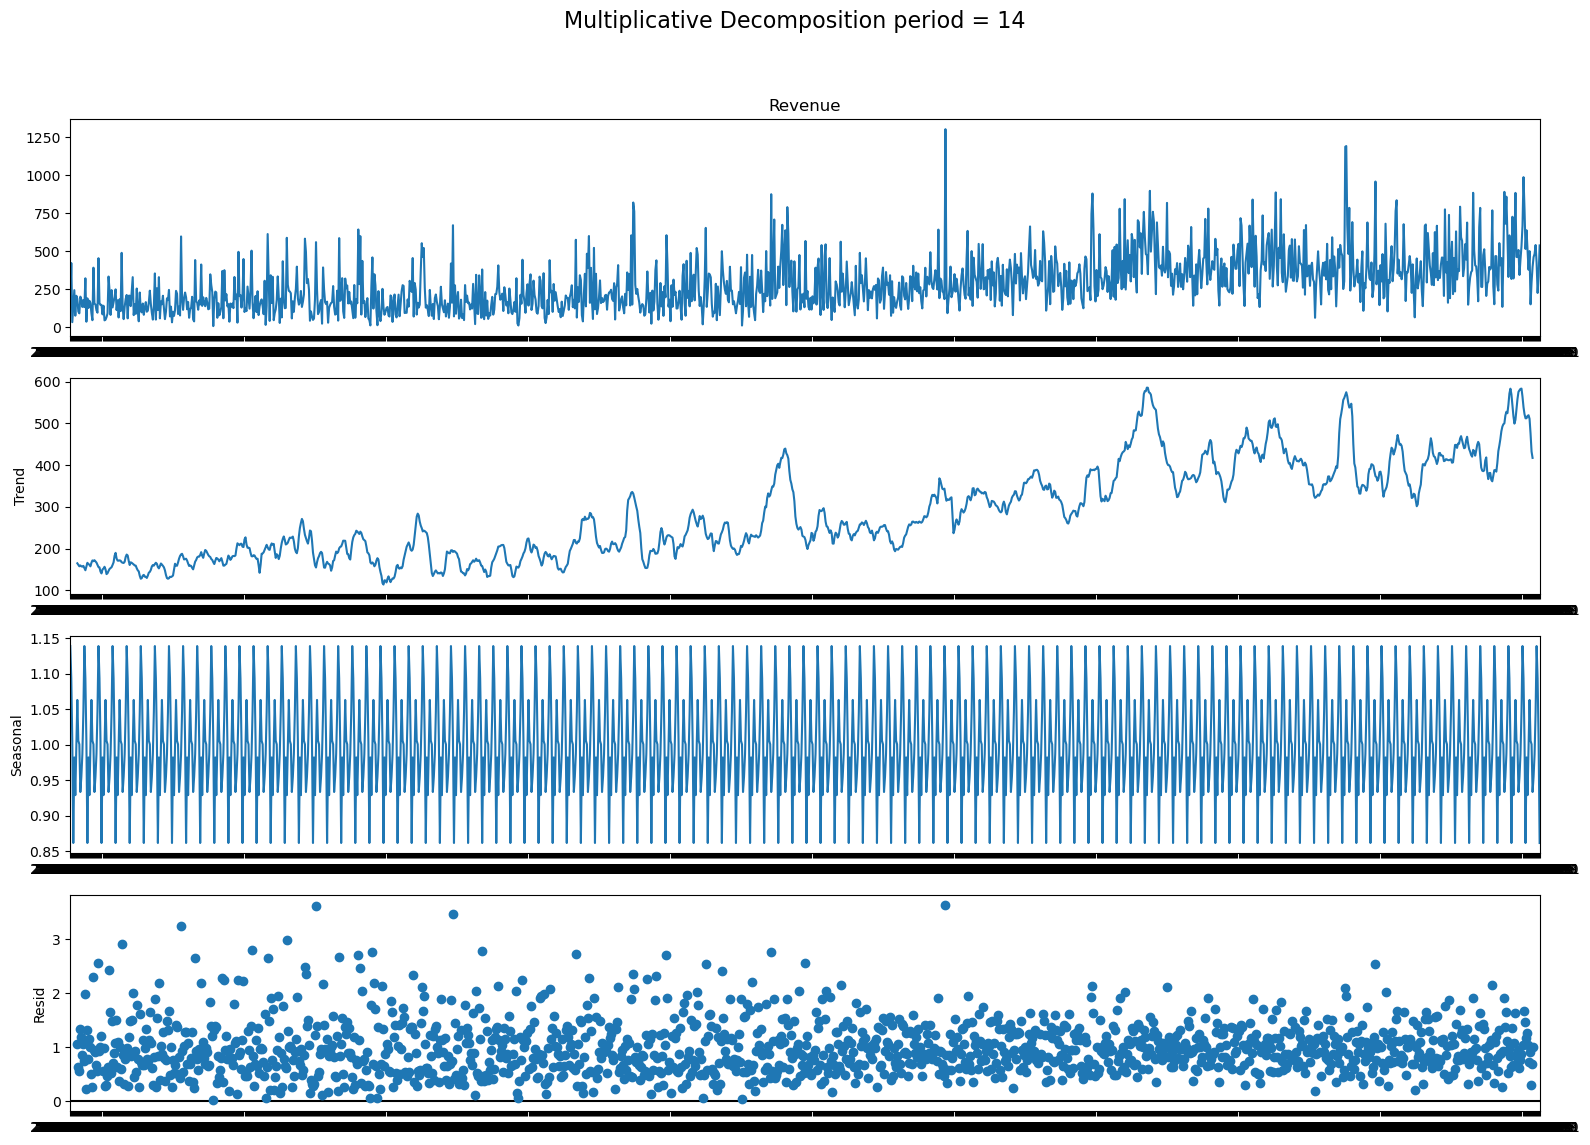

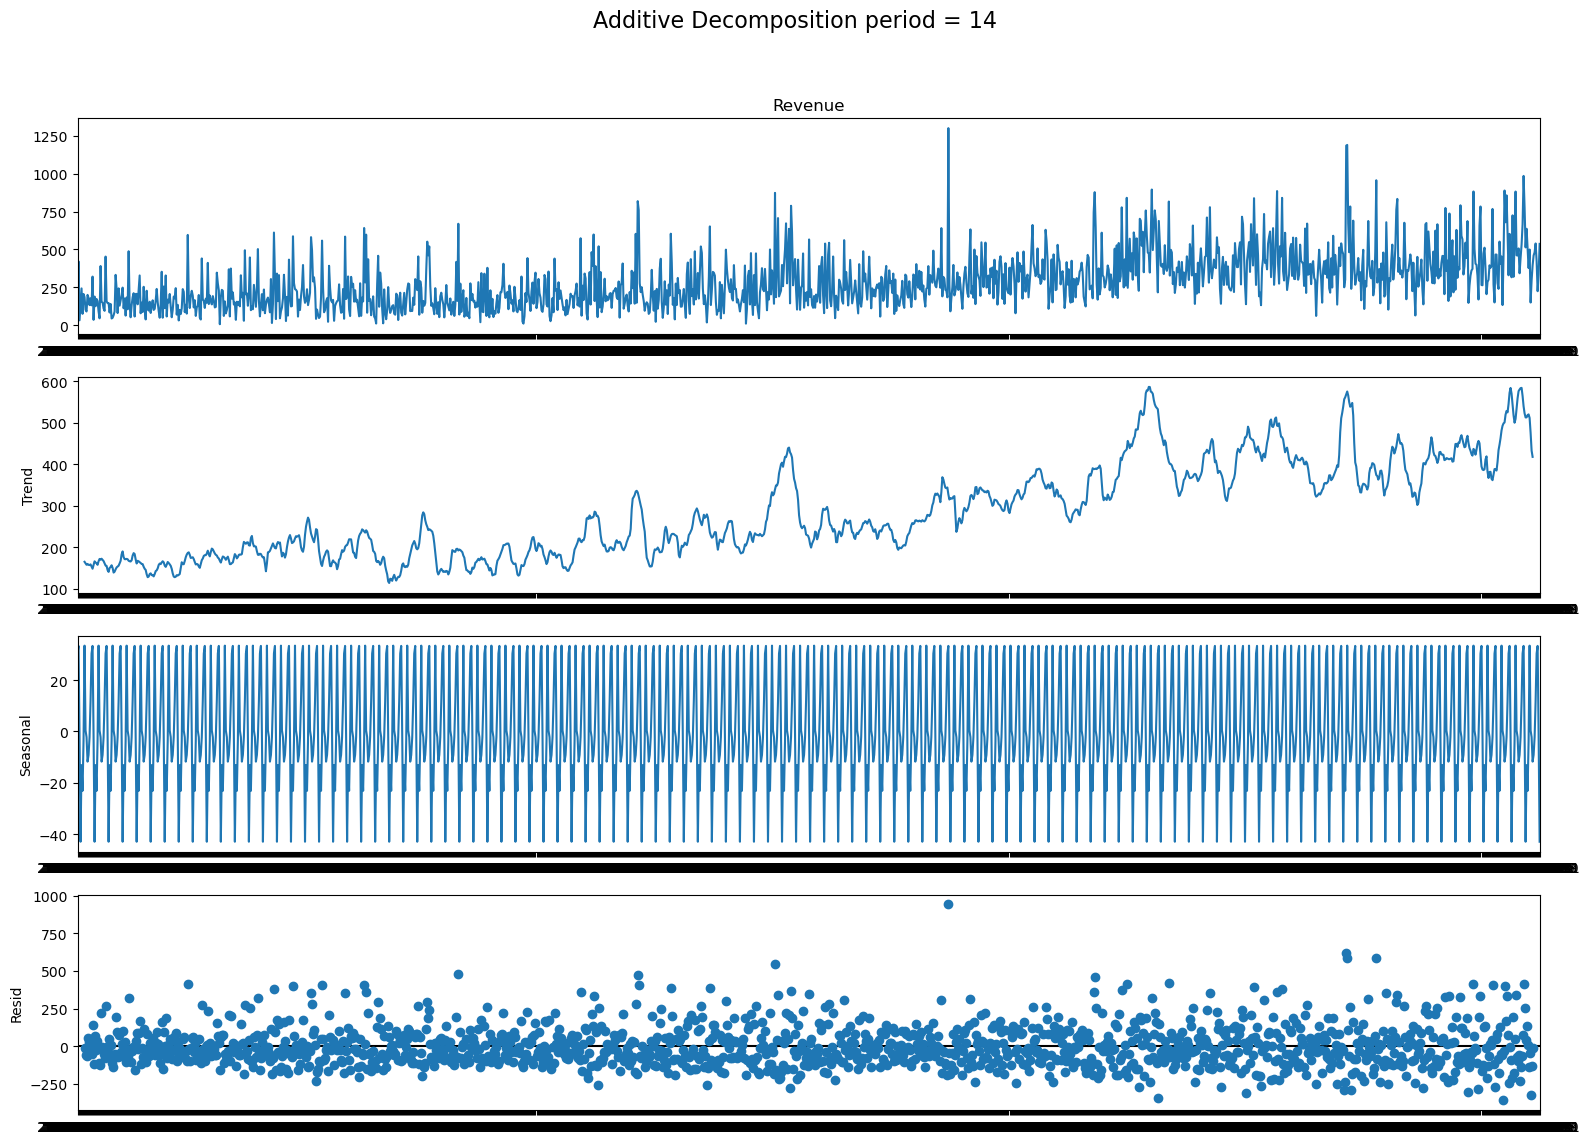

In [ ]:
# Multiplicative Decomposition 
multiplicative_decomposition = seasonal_decompose(CA_only["Revenue"], model='multiplicative', period=14)

# Additive Decomposition
additive_decomposition = seasonal_decompose(CA_only["Revenue"], model='additive', period=14)

# Plot
plt.rcParams.update({'figure.figsize': (16,12)})
multiplicative_decomposition.plot().suptitle('Multiplicative Decomposition period = 14', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

additive_decomposition.plot().suptitle('Additive Decomposition period = 14', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()

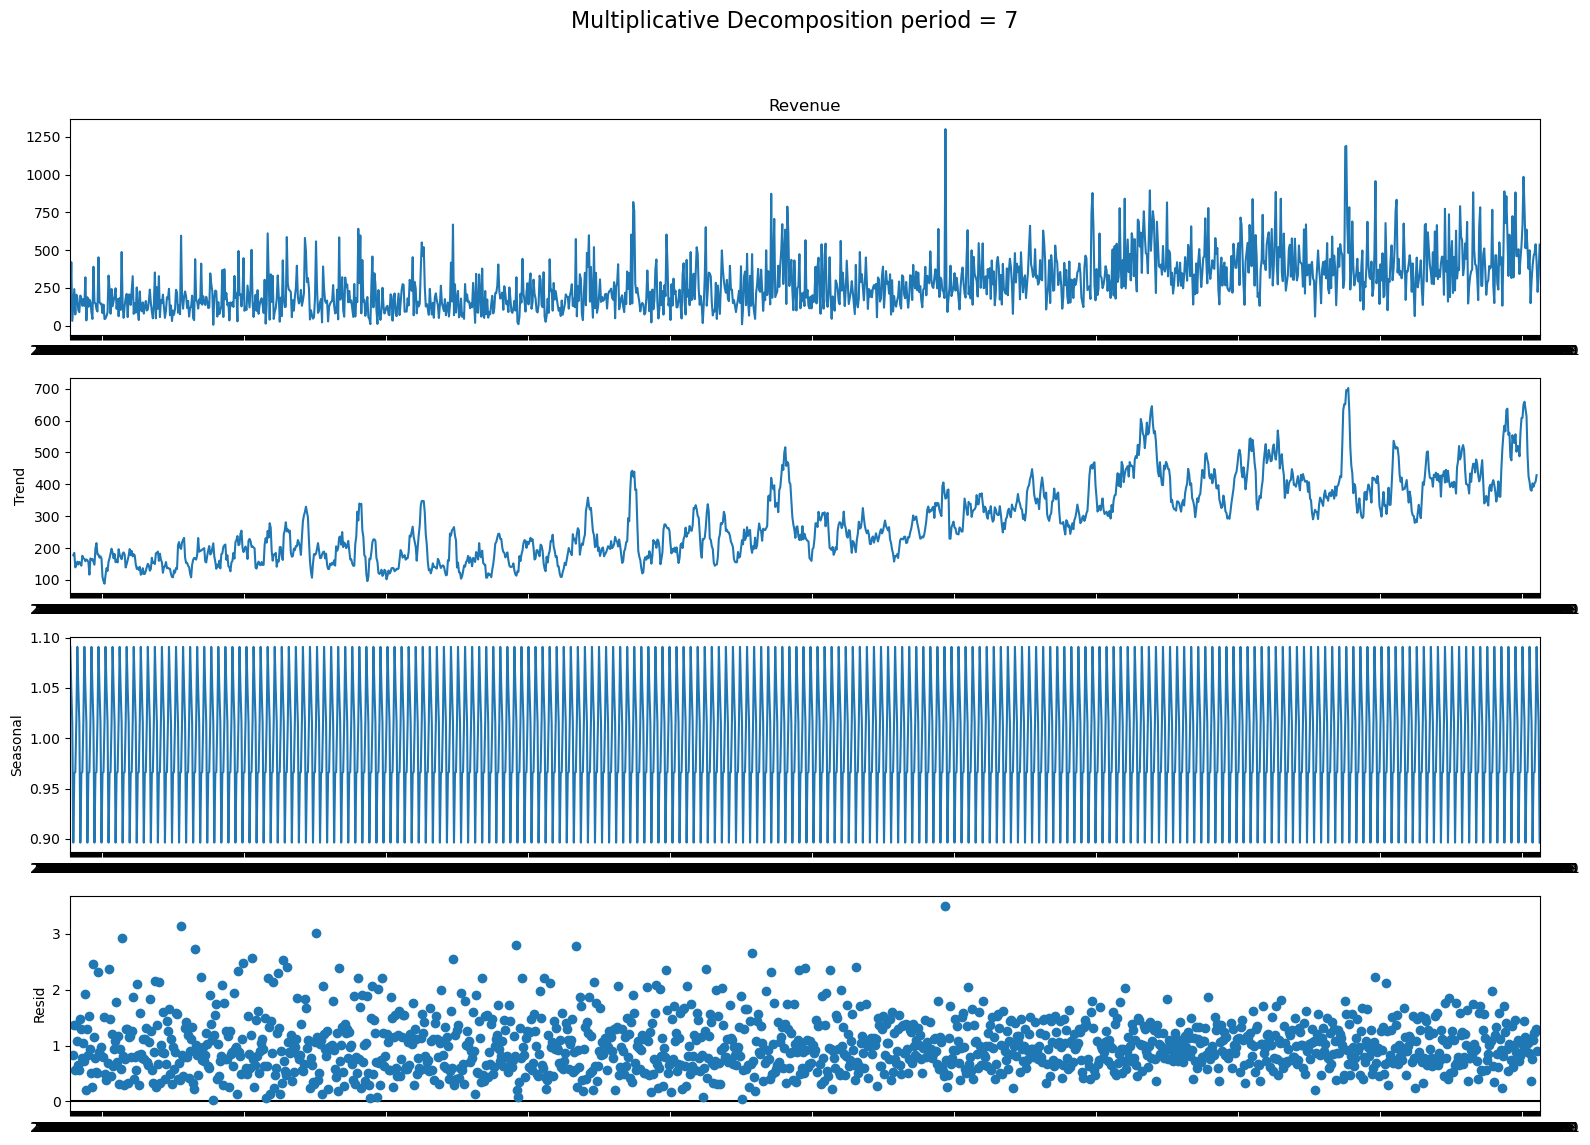

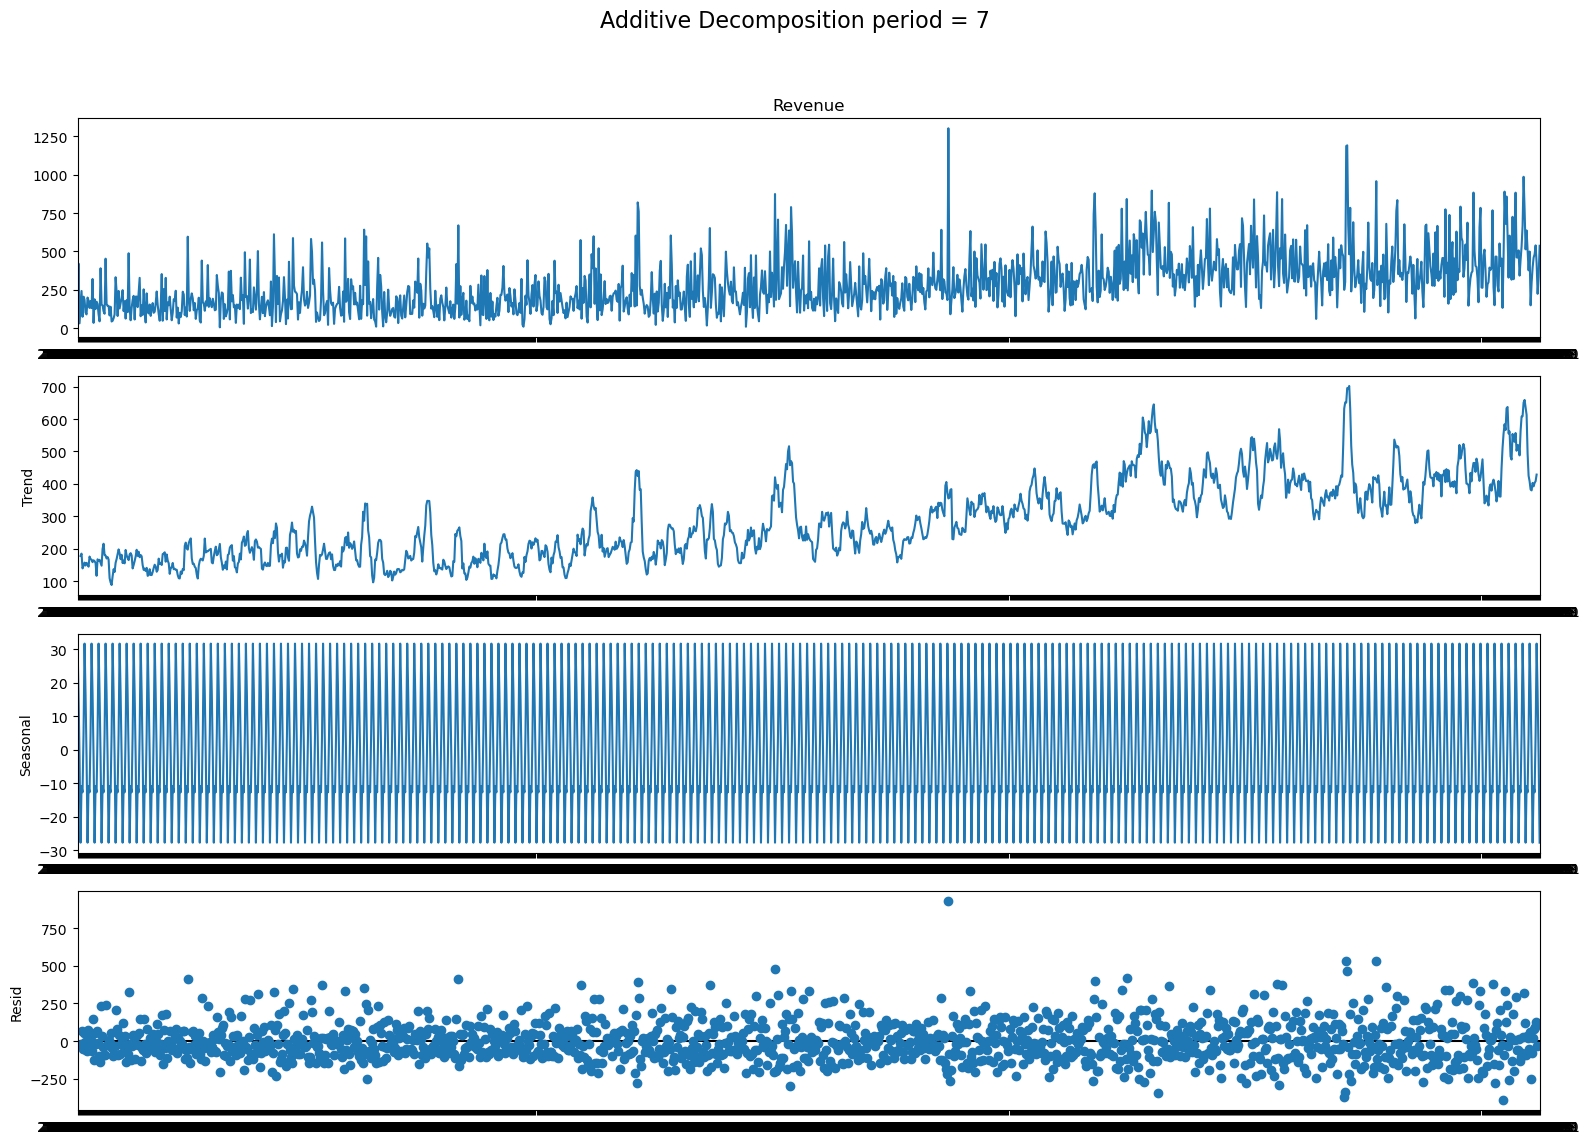

In [ ]:
# Multiplicative Decomposition 
multiplicative_decomposition = seasonal_decompose(CA_only["Revenue"], model='multiplicative', period=7)

# Additive Decomposition
additive_decomposition = seasonal_decompose(CA_only["Revenue"], model='additive', period=7)

# Plot
plt.rcParams.update({'figure.figsize': (16,12)})
multiplicative_decomposition.plot().suptitle('Multiplicative Decomposition period = 7', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

additive_decomposition.plot().suptitle('Additive Decomposition period = 7', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()

Analysis of the Plots using Claude AI: 

#### Period = 30 days (Images 1 & 2):
Strong seasonal pattern with clear monthly cycles
Smoother trend component
Multiplicative model shows more consistent residuals compared to additive
Seasonal factors range from 0.85 to 1.2 (multiplicative) vs -40 to +60 (additive)


#### Period = 14 days (Images 3 & 4):
Bi-weekly patterns become visible
Trend line becomes slightly more volatile
Seasonal patterns are more frequent but still regular
Multiplicative decomposition maintains better residual stability


#### Period = 7 days (Images 5 & 6):
Weekly patterns are now visible
Trend component becomes more volatile
Seasonal patterns are very frequent
Residuals remain more stable in multiplicative model

Key Observations:

The multiplicative model appears superior across all periods because:

More consistent residual patterns regardless of the revenue level
Better handling of the increasing variance in the data
More stable seasonal factors


Period Selection:

Period = 30 shows the cleanest decomposition with:

Smoothest trend component
Clear seasonal patterns
Well-behaved residuals


Shorter periods (14, 7) introduce more noise in the trend component

### Detrending Revenue

Text(0.5, 1.0, 'Daily Revenue detrended by subtracting the trend component')

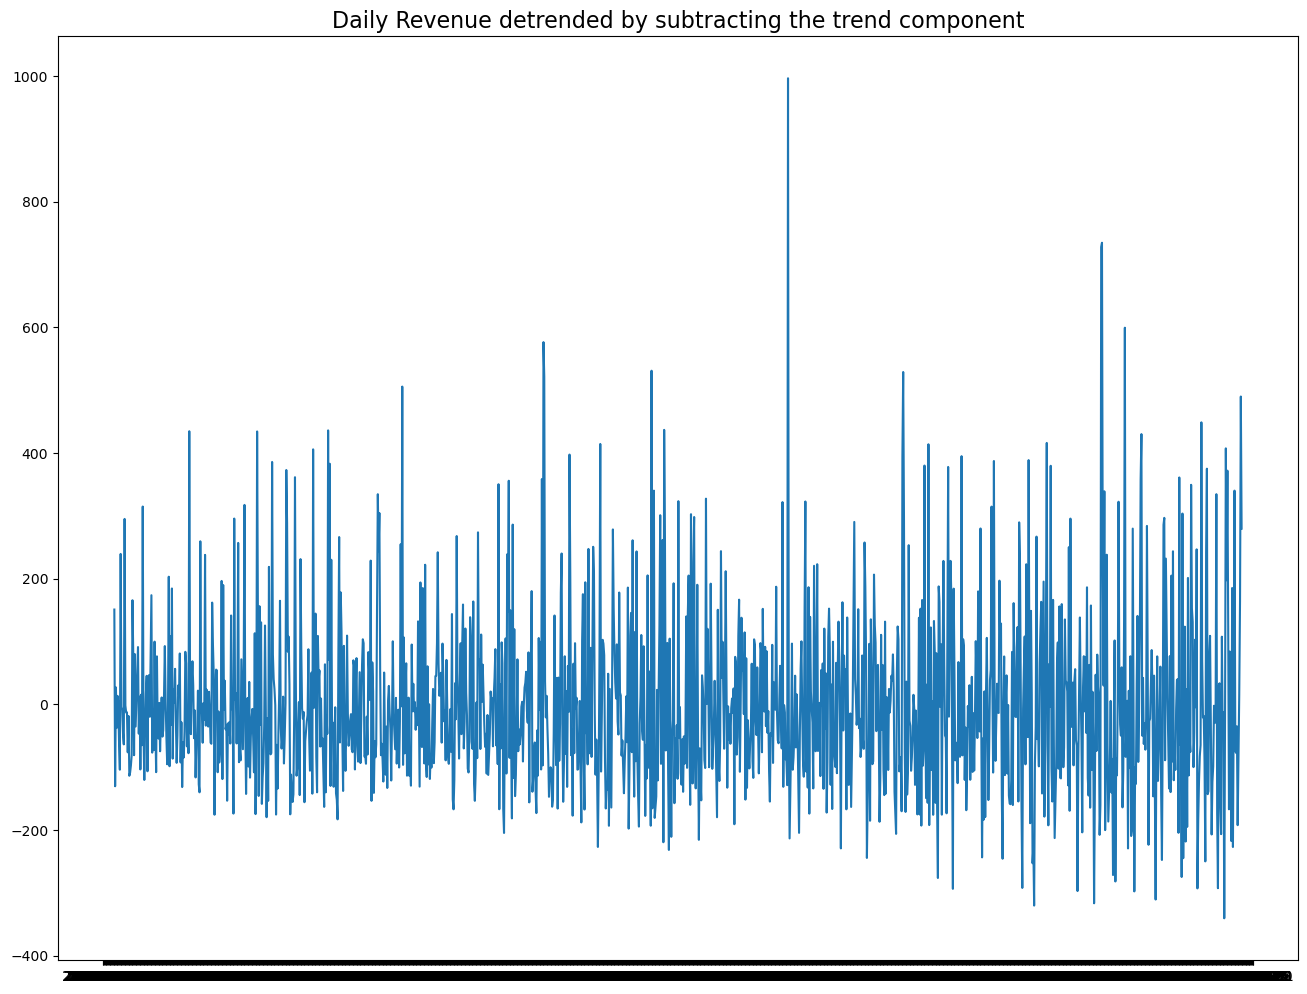

In [ ]:
# Using statmodels: Subtracting the Trend Component
from statsmodels.tsa.seasonal import seasonal_decompose
result_mul = seasonal_decompose(CA_only["Revenue"], model='multiplicative', period=30)
detrended = CA_only["Revenue"].values - result_mul.trend
plt.plot(detrended)
plt.title('Daily Revenue detrended by subtracting the trend component', fontsize=16)

In [ ]:
detrended_filtered = detrended[29:]
detrended_filtered = detrended_filtered[:-15]

adf_result = adfuller(detrended_filtered)
test_statistic, p_value, _, _, _, _ = adf_result
print(f'Test Statistic: {test_statistic}')
print(f'P-value: {p_value}')

Test Statistic: -12.198278452576526
P-value: 1.240023078755318e-22


### Deseasonalizing Temperature

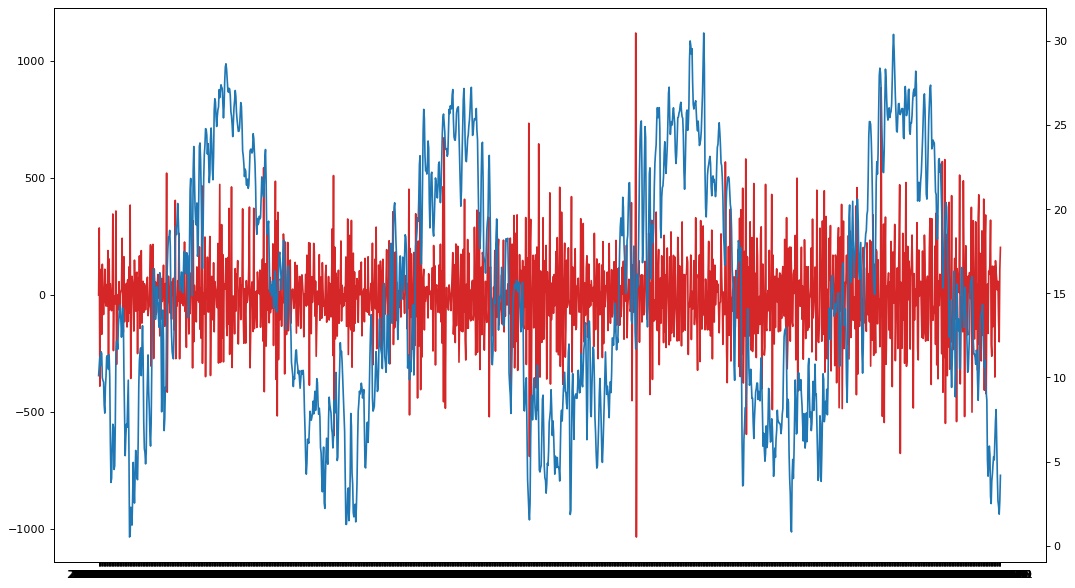

In [ ]:
CA_plot = CA_only.reset_index()

fig, ax1 = plt.subplots(1,1,figsize=(16,9), dpi= 80)


ax1.plot(CA_plot["Order Date"],
            CA_plot["first_oder_diff"],
            color="tab:red")

# Second line
ax2 = ax1.twinx()
ax2.plot(CA_plot["Order Date"],
         CA_plot["tavg"],
         color="tab:blue")


In [ ]:
CA_only["Temp_No_Season"] = CA_only["tavg"] - CA_only["tavg"].shift(12*30)

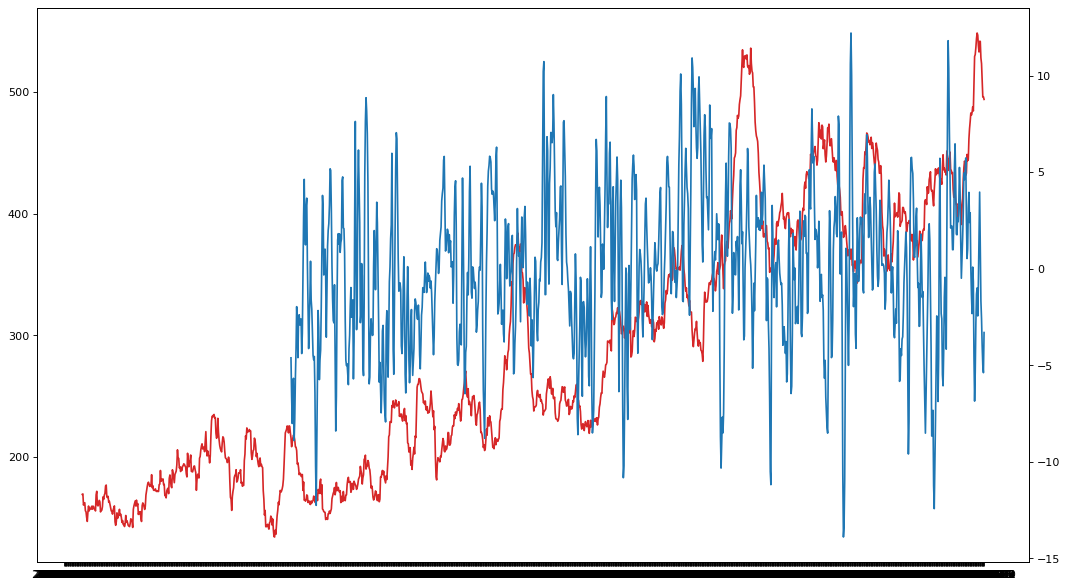

In [ ]:
CA_plot = CA_only.reset_index()

fig, ax1 = plt.subplots(1,1,figsize=(16,9), dpi= 80)


ax1.plot(CA_plot["Order Date"],
            CA_plot["Revenue_SMA30"],
            color="tab:red")

# Second line
ax2 = ax1.twinx()
ax2.plot(CA_plot["Order Date"],
         CA_plot["Temp_No_Season"],
         color="tab:blue")
